# Structure of Spheroid Microscopy data

In this section, we will dicuss the structure of the spheroid microscopy images. This is managed in the `SpheroidPy.spheroid` modul. It follows a hierarchical structure, starting from individual (multichannel) images (`SpheroidImage`), from which instances from multiple timepoints can be combined in a timeseries (`SpheroidSeries`), from which then in turn multiple replicates can be combined in a collection (`SpheroidCollection`) for statistical analysis.

If `SpheroidPy` is not installed on your system yet, we have to import its folder to the Python module search path:

In [8]:
%load_ext autoreload
%autoreload 2

import sys
sys.path.append('../../SpheroidPy')

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## __SpheroidImage:__  Individual (multichannel) Microscope Images

<img src="../docs/source/_images/example_SpheroidImage.png" width="400em" align="right" style="margin-left: 20px; margin-bottom: 20px; margin-top: -20px;" />

The `SpheroidImage` class is the most basic building block of SpheroidPy. It manages the microscopy images of different channels for one measurement of a spheroid. 

After loading the images, they can be segmented using different channels and methods (thresholding or deep learning).

In addition, mathematical calculations that only concern the Image are implemented in this class. For example, different quatifications using fluorescence intensities, radial profiles and even diffusion distributions using differential equations can be calculated using this class.


#### __Creating a `SpheroidImage`:__
We start by importing the class

In [8]:
from SpheroidPy.spheroid import SpheroidImage

Information on what the class does and what parameters we need as input can be seen by typing

In [ ]:
SpheroidImage?

So now we can create a Spheroid based on a brightfield/phase contrast image and optionally fluorescence images

In [9]:
# specify the paths of your Images
path_pc='example_data/PhaseContrast/HCT116_SpheroidProliferation_PhaseContrast_raw_C5_1_2025y05m20d_18h00m.tif'          #PhaseContrast
path_green='example_data/FluorescenceGreen/HCT116_SpheroidProliferation_fluorescence_green_C5_1_2025y05m20d_18h00m.tif'  #green Fluorescence
path_red='example_data/FluorescenceRed/HCT116_SpheroidProliferation_fluorescence_red_C5_1_2025y05m20d_18h00m.tif'        #red Fluorescence

# create a SpheroidImage
my_spheroid = SpheroidImage(brightfield = path_pc, fluorescence_green = path_green, fluorescence_red = path_red, #paths
                           image_size = (1700,1270)) # size of image in x- and y-direction [µm]

We can test the images to see if everything worked and the Spheroid has been created successfully

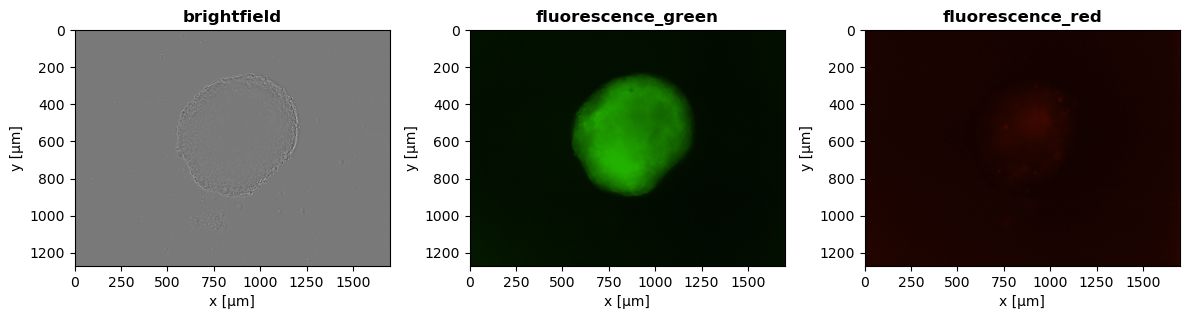

In [11]:
my_spheroid.show()

#### __Basic Usage:__
Now that we are familiar with the creation of SpheroidImages, we can start extracting some valueable information out of it. As for that we almost always need to know the exact boundary of the spheroid first, we start by segmenting the spheroid. For that two methods have been implemented:
1. Thresholding: ... (usually based on fluorescence color expressed in all cells)
2. Deep learning: ... (most useful for brightfield/phase contrast or similar fluorescence as before)
3. Manual:

In [212]:
my_spheroid.segmentation_detectron('brightfield', thres=.99)

array([[735., 185.],
       [734., 186.],
       [724., 186.],
       ...,
       [787., 186.],
       [782., 186.],
       [781., 185.]], dtype=float32)

In [199]:
my_spheroid.segmentation_thresholding('fluorescence_green', 1.4)

array([[1012. , 1034.5],
       [1011. , 1034.5],
       [1010. , 1034.5],
       ...,
       [1012.5, 1033. ],
       [1012.5, 1034. ],
       [1012. , 1034.5]], dtype=float32)

`segmentation()` method also prvides border reconstruction

In [12]:
my_spheroid.segmentation(border_margin=10)

Text

In [13]:
my_spheroid.segmentation_manual('brightfield')

The result can be überprüft with

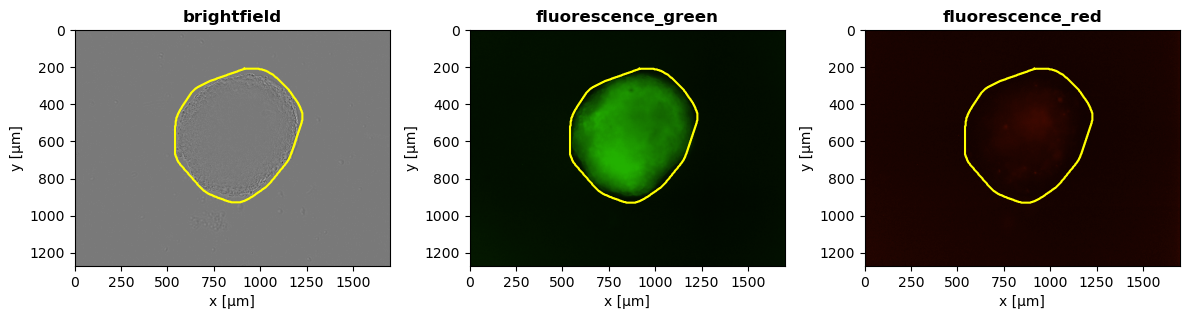

In [15]:
my_spheroid.show()

In [246]:
my_spheroid.contour_touches_border

False

In [17]:
my_spheroid.radius, my_spheroid.area, my_spheroid.metric_fluorescence('green')

(341.5640612523049, 366517.0734653396, (16877266, 68.45927878959964))

#### __Advanced Usage:__
After performing the segmentation, it is also possible to get more advanced information from the provided images. 
This section aims to give an overview over some examples for that.


__Radial Profiles:__
Text

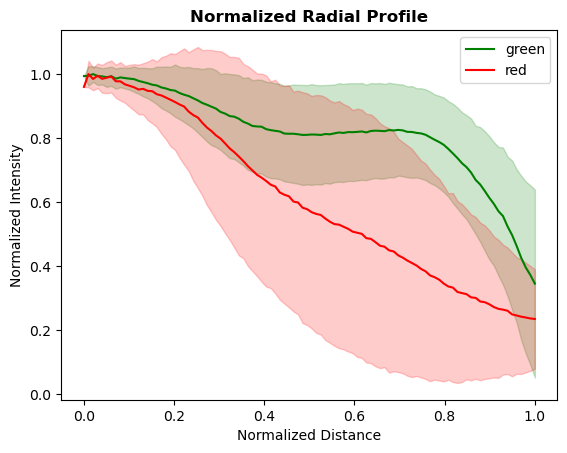

{'mean_radius': 368.854602565547,
 'intensity_profiles': {'green': {'mean': array([0.99388268, 0.99446886, 1.        , 0.9940663 , 0.99276618,
          0.99022203, 0.99330786, 0.98575837, 0.98963223, 0.98750163,
          0.9857627 , 0.9842498 , 0.97872474, 0.97507561, 0.97143615,
          0.96679038, 0.96459531, 0.95823528, 0.95508195, 0.95015965,
          0.94831124, 0.94077461, 0.93550215, 0.93140242, 0.92455111,
          0.91773908, 0.90963222, 0.90424869, 0.8980972 , 0.89204628,
          0.881654  , 0.87653379, 0.86877377, 0.86697288, 0.86060517,
          0.85091055, 0.84537366, 0.83784527, 0.83642062, 0.83563865,
          0.82801457, 0.8248662 , 0.82276829, 0.82067426, 0.81421107,
          0.8136085 , 0.81372487, 0.81197651, 0.80988905, 0.81025851,
          0.81131939, 0.81088076, 0.809892  , 0.81283071, 0.81186284,
          0.81494883, 0.81760194, 0.81614038, 0.81881987, 0.81856381,
          0.81945747, 0.82083992, 0.81771478, 0.82231067, 0.82326609,
          0.82260

In [102]:
my_spheroid.radial_profile(channels=['green', 'red'], plot=True, angle_step=2)

__Diffusion Distribution:__
Text

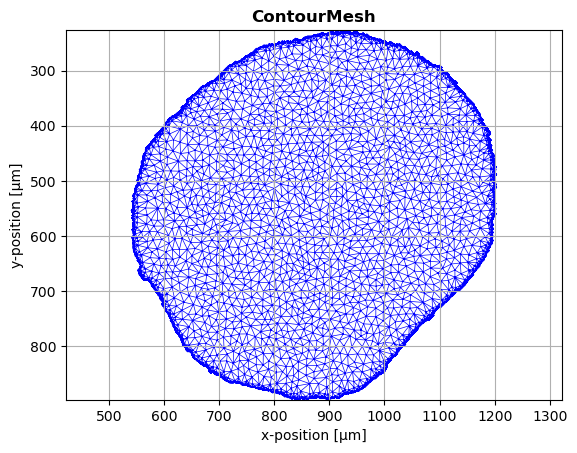

(array([[692.        , 734.5       ],
        [691.        , 734.5       ],
        [690.5       , 734.        ],
        ...,
        [578.59399201, 431.20183265],
        [526.60325609, 355.48232023],
        [569.15034666, 380.38310746]]),
 array([[ 830, 2616, 3071],
        [2124, 3512, 3062],
        [ 826,  827, 2617],
        ...,
        [5259, 5860, 4630],
        [5828, 5861, 4790],
        [4860, 5861, 4827]]))

In [111]:
my_spheroid.mesh(max_area=100)

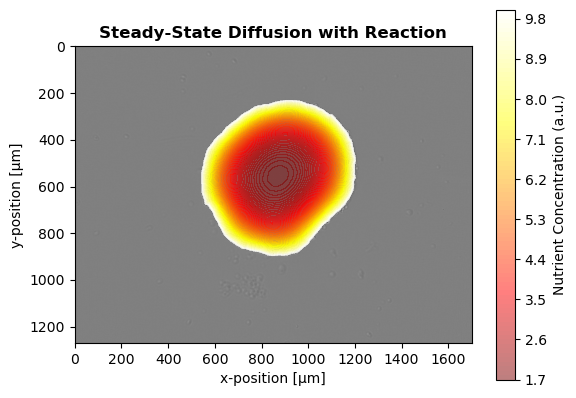

(array([[692.        , 734.5       ],
        [678.5       , 732.        ],
        [666.        , 726.5       ],
        ...,
        [558.08610252, 665.06900169],
        [712.1774571 , 411.01106806],
        [707.46834051, 395.24444766]]),
 array([[475,  39,  40],
        [152, 103, 171],
        [475,  41, 260],
        ...,
        [518, 660, 513],
        [426, 661, 408],
        [427, 661, 428]]),
 array([10.        , 10.        , 10.        , 10.        , 10.        ,
        10.        , 10.        , 10.        , 10.        , 10.        ,
        10.        , 10.        , 10.        , 10.        , 10.        ,
        10.        , 10.        , 10.        , 10.        , 10.        ,
        10.        , 10.        , 10.        , 10.        , 10.        ,
        10.        , 10.        , 10.        , 10.        , 10.        ,
        10.        , 10.        , 10.        , 10.        , 10.        ,
        10.        , 10.        , 10.        , 10.        , 10.        ,
        

In [127]:
my_spheroid.diffusion_stationary(
    boundary_value = 10,
    diffusion_rate = 2000,
    reaction_rate = .1,
    plot = True,
    accuracy = 20)

## __SpheroidSeries:__ Timeseries of multiple SpheroidImages
<img src="../docs/source/_images/example_SpheroidSeries.png" width="400em" align="right" style="margin-left: 20px; margin-bottom: 30px; margin-top: -30px;" />

In Experiments it often is necessary to observe a spheroid over a longer period for different timepoints. 
To simplify the data handling of such processes, multiple `SpheroidImage` instances of the same spheroid at different timepoints can be combined into one `SpheroidSeries`. 
This allows for the management of time-lapse microscopy data and investigation of the evolution of the spheroid over time.

#### __Creating `SpheroidSeries`:__
Similarly, first an instance of the `SpheroidSeries` class has to initiated. Afterwards multiple `SpheroidImage` instances can be added.
In our case we take a look at the previous Spheroid from Well C5 for which we have images taken after every 48h.


In [8]:
from SpheroidPy.spheroid import SpheroidSeries, SpheroidImage    # import of the class
from datetime import datetime                     # module for timepoints

spheroid_series = SpheroidSeries('My SpheroidSeries Name')

In [10]:
# creating and adding SpheroidImages for every 48h
for day in range(10,26,2):
    # timepoint of image
    date_time = datetime.strptime(f'2025y05m{day}d_18h00m', '%Yy%mm%dd_%Hh%Mm')
    # path of the image channels
    path_pc=f'example_data/PhaseContrast/HCT116_SpheroidProliferation_PhaseContrast_raw_C5_1_2025y05m{day}d_18h00m.tif'          #PhaseContrast
    path_green=f'example_data/FluorescenceGreen/HCT116_SpheroidProliferation_fluorescence_green_C5_1_2025y05m{day}d_18h00m.tif'  #green Fluorescence
    path_red=f'example_data/FluorescenceRed/HCT116_SpheroidProliferation_fluorescence_red_C5_1_2025y05m{day}d_18h00m.tif'        #red Fluorescence

    # create a SpheroidImage
    my_spheroid = SpheroidImage(brightfield = path_pc, fluorescence_green = path_green, fluorescence_red = path_red, image_size = (1700,1270))
    # add to SpheroidSeries
    spheroid_series.add_spheroid_image(my_spheroid, date_time)

We can now visualise our Series using an interactive build-in method:

In [14]:
spheroid_series.show()

#### __Basic Usage:__
In a next step, the images have to be segmented first in order to identify the evolution of the spheroids over time. This can be done in a similar way is previously

In [12]:
spheroid_series.segmentation(methods=[('thresholding', 'fluorescence_green'),('ai', 'brightfield')], threshold=1.2, border_margin=7)

Segmentation finished: 8/8 images segmented successfully.


Afterwards the segmentation can be überprüft using the `show()` method or by ...

There are currently the following metrics available
- based on contour: 'radius', 'area'
- based on fluorescence intensity: 'fluorescence_(color)_ cumulative' or 'fluorescence_(color)_mean'


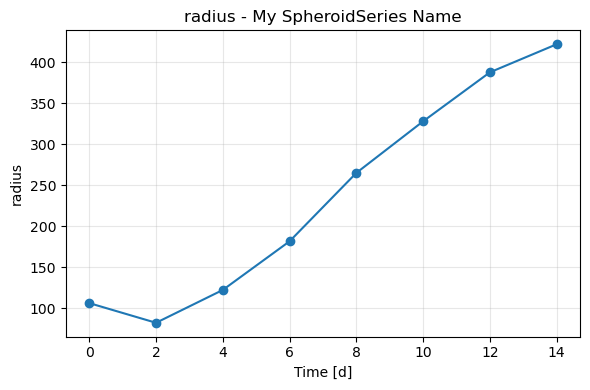

,My SpheroidSeries Name
0.0,106.395404
48.0,82.391511
96.0,122.436483
144.0,181.764387
192.0,265.170748
240.0,328.095834
288.0,387.854667
336.0,422.093242


In [150]:
spheroid_series.metric('radius', plot=True)

If it is desired to restrict the investigation to certain time peroids during the experiment, this can be done using the `TimePeroid` class which manages ... and is embedded into the `SpheroidSeries` class via the following method

In [16]:
spheroid_series.time_period('Proliferation', start_time='2025-05-14 18:00:00', end_time='2025-05-24 18:00:00')

TimePeriod(name='Proliferation', start=2025-05-14 18:00:00, end=2025-05-24 18:00:00)

##### __Exporting Videos:__
The resulting figures or ... can be saved locally. In addition, videos of both inidivual channels as well as overlay of several ... can be exported for visualisation purposes.

In [14]:
spheroid_series.export_video?

Signature:
spheroid_series.export_video(
    channel: str = 'brightfield',
    overlay_channels: list[str] = [],
    increases: list[str] = [],
    video_name: str = 'test.mp4',
    scalebar: bool = True,
    fps: int = 5,
    contour: bool = True,
    time: bool = True,
    exclude_out_of_contour: bool = True,
    diffusion_dict: dict = {},
)
Docstring:
Exports the spheroid series images to a video.

:param parent_folder:
:param channel: Channel to export (default: brightfield)
:param overlay: other channels/contours/fields, that get overlayed (default: none)
:param format: format of the video (default: ???)
:return:
File:      ~/Documents/Labor/SpheroidPy/SpheroidPy/spheroid/spheroid_series.py
Type:      method

##### __Custom Analysis:__

Text

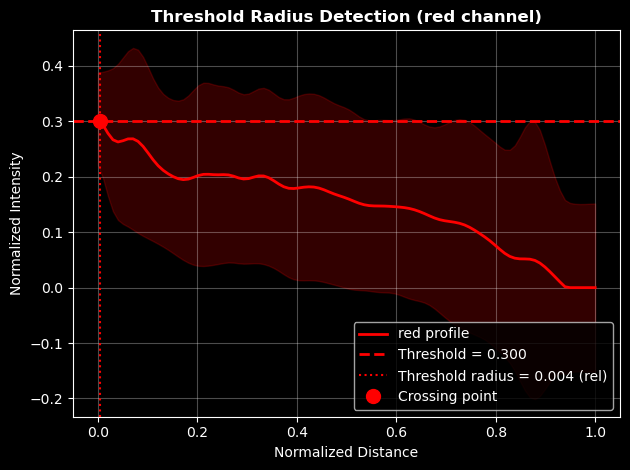

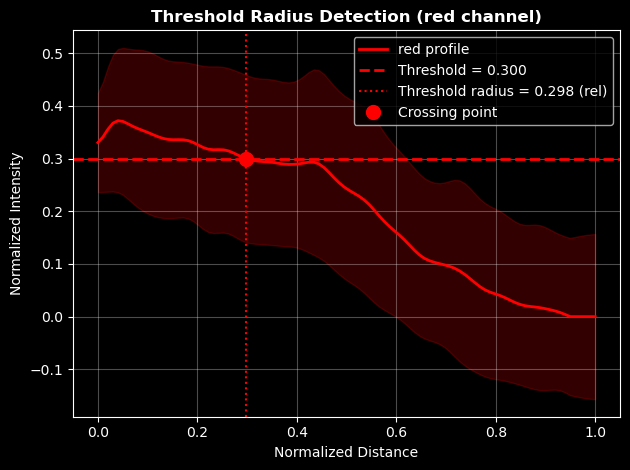

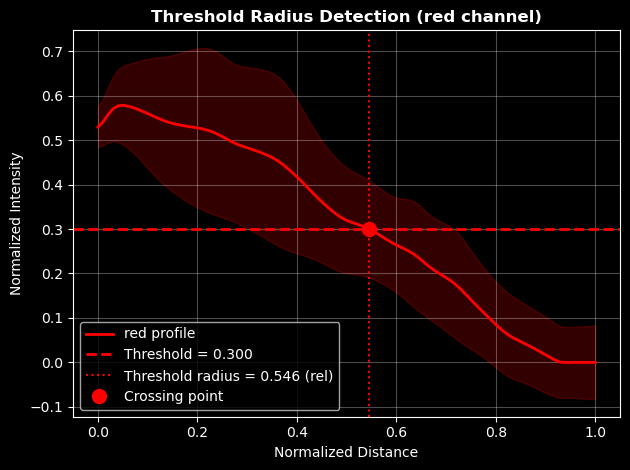

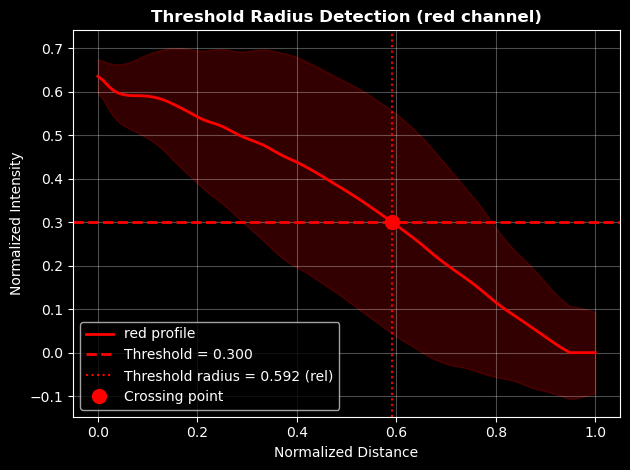

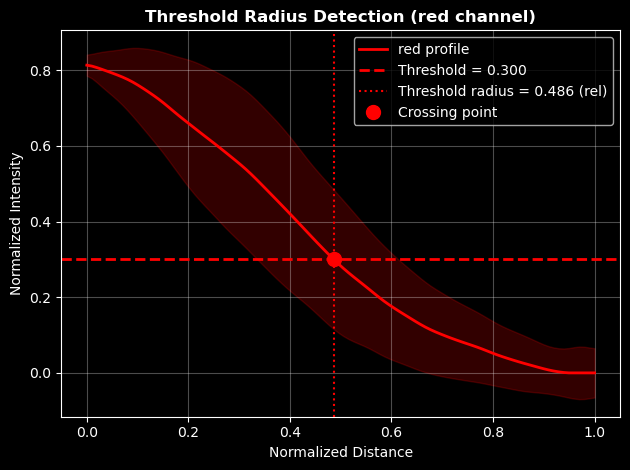

In [381]:
for sp, num in zip(list(spheroid_series.spheroid_image_dict.values())[3:], range(10)):
    sp.analysis_results = {}
    sp.thr_radius('red',0.3,background_subtraction=True,plot=True)

In [372]:
dic = spheroid_series.necrotic_radius(time_period='Proliferation', fit=True)

[autoreload of SpheroidPy.spheroid.spheroid_series failed: Traceback (most recent call last):
  File "/opt/anaconda3/envs/lab/lib/python3.10/site-packages/IPython/extensions/autoreload.py", line 273, in check
    superreload(m, reload, self.old_objects)
  File "/opt/anaconda3/envs/lab/lib/python3.10/site-packages/IPython/extensions/autoreload.py", line 471, in superreload
    module = reload(module)
  File "/opt/anaconda3/envs/lab/lib/python3.10/importlib/__init__.py", line 169, in reload
    _bootstrap._exec(spec, module)
  File "<frozen importlib._bootstrap>", line 619, in _exec
  File "<frozen importlib._bootstrap_external>", line 879, in exec_module
  File "<frozen importlib._bootstrap_external>", line 1017, in get_code
  File "<frozen importlib._bootstrap_external>", line 947, in source_to_code
  File "<frozen importlib._bootstrap>", line 241, in _call_with_frames_removed
  File "/Users/cedric/Documents/Labor/SpheroidPy/examples/../../SpheroidPy/SpheroidPy/spheroid/spheroid_series

TypeError: SpheroidSeries.necrotic_radius() got an unexpected keyword argument 'fit'

In [375]:
data = {
    "R1": [
        {"growth_rate": 20.6, "critical_radius": 337.1},
        {"growth_rate": 21.0, "critical_radius": 335.9},
        {"growth_rate": 20.4, "critical_radius": 338.0},
    ],
    "R2": [
        {"growth_rate": 19.9, "critical_radius": 332.1},
        {"growth_rate": 20.1, "critical_radius": 334.3},
        {"growth_rate": 19.7, "critical_radius": 333.0},
    ],
    "R3": [
        {"growth_rate": 21.3, "critical_radius": 340.0},
        {"growth_rate": 21.2, "critical_radius": 339.5},
        {"growth_rate": 21.1, "critical_radius": 339.8},
    ]
}


import numpy as np

def mean_and_sem(values):
    """Berechnet Mittelwert und Standardfehler."""
    values = np.array(values, dtype=float)
    mean = np.mean(values)
    sem = np.std(values, ddof=1) / np.sqrt(len(values))
    return mean, sem


def analyze_replicates(data, parameters=("growth_rate", "critical_radius")):
    """
    Berechnet:
      1. Für jeden Replikat (R1, R2, ...) den Mittelwert & Fehler.
      2. Aus diesen Mittelwerten den Gesamtmittelwert & Fehlerfortpflanzung.
    """
    replicate_stats = {}
    overall_stats = {}

    # --- Schritt 1: pro Replikat ---
    for rep_name, entries in data.items():
        replicate_stats[rep_name] = {}
        for param in parameters:
            values = [entry[param] for entry in entries if param in entry]
            mean, sem = mean_and_sem(values)
            replicate_stats[rep_name][param] = {"mean": mean, "error": sem}

    # --- Schritt 2: über Replikate ---
    for param in parameters:
        means = [replicate_stats[rep][param]["mean"] for rep in replicate_stats]
        errors = [replicate_stats[rep][param]["error"] for rep in replicate_stats]

        # Mittelwert der Mittelwerte
        overall_mean = np.mean(means)

        # Fehlerfortpflanzung:
        # kombinierter Fehler aus Streuung der Mittelwerte + individuelle Fehler
        # σ_total² = σ_means² + mean(σ_replicate²)
        variance_of_means = np.var(means, ddof=1)
        mean_internal_var = np.mean(np.array(errors) ** 2)
        total_error = np.sqrt(variance_of_means + mean_internal_var)

        overall_stats[param] = {"mean": overall_mean, "error": total_error}

    return replicate_stats, overall_stats


# Beispiel:
replicate_stats, overall_stats = analyze_replicates(data)

print("Einzelergebnisse pro Replikat:")
for r, vals in replicate_stats.items():
    print(f"  {r}: {vals}")

print("\nGesamtmittelwerte:")
for p, vals in overall_stats.items():
    print(f"  {p}: {vals['mean']:.3f} ± {vals['error']:.3f}")


Einzelergebnisse pro Replikat:
  R1: {'growth_rate': {'mean': 20.666666666666668, 'error': 0.17638342073763966}, 'critical_radius': {'mean': 337.0, 'error': 0.6082762530298295}}
  R2: {'growth_rate': {'mean': 19.900000000000002, 'error': 0.11547005383792577}, 'critical_radius': {'mean': 333.1333333333334, 'error': 0.6385748020222646}}
  R3: {'growth_rate': {'mean': 21.2, 'error': 0.05773502691896237}, 'critical_radius': {'mean': 339.76666666666665, 'error': 0.1452966314513562}}

Gesamtmittelwerte:
  growth_rate: 20.589 ± 0.666
  critical_radius: 336.633 ± 3.372


In [158]:
time = dic['time']
radii = dic['outer_radius'] + dic['necrotic_radius']

from scipy.optimize import curve_fit
p0 = [radii[0], 0.005, 0.8, 0.05, 0.1, 0.5, 0.9, 1, 1]
lower_bounds = [0.9*radii[0], 0, 0, 0, 0, 0, 0, 1, 1]
uppper_bounds = [1.1*radii[0], 0.1, 1, 1, 1, 1, 1, 10, 10]
bounds = [lower_bounds, uppper_bounds]

# --- Fixe Parameter definieren ---
dt = 0.01
dxi = 0.1
tol = 1e-6
max_newton_iter = 100
relaxation = 0.8
check_stability = True
plot = False

# --- Modell für curve_fit mit lambda ---
# Nur bis m2 sind freie Parameter
fit_func = lambda t, R0, beta, BA, CD, CC, sigma, delta, m1, m2: model(t, R0,beta,BA,CD,CC,sigma,delta,m1,m2,dt,dxi,tol,max_newton_iter,relaxation,check_stability,plot)


#popt, pcov = curve_fit(fit_func, time, radii, p0=p0, bounds=bounds)

In [184]:
from SpheroidPy.spheroid.models.ward_and_king import WardAndKing

model = WardAndKing(l=20, tf=.01, dt=0.1, dxi=0.005)

<Figure size 1000x800 with 0 Axes>

Time: 15.000, Iterations: 47:  65%|██████▌   | 261/400 [00:00<00:00, 616.26it/s]/Users/cedric/Documents/Labor/SpheroidPy/examples/../../SpheroidPy/SpheroidPy/spheroid/models/ward_and_king.py:1020: UserWarning: Newton iterations did not converge at step 300, t=15.050 after 50 iterations. Residual: 1.09e-06
  self.c[j] = 1/self.dxi**2 + 1/(self.xi[j]*self.dxi)
Time: 15.050, Iterations: 50:  65%|██████▌   | 261/400 [00:00<00:00, 616.26it/s]/Users/cedric/Documents/Labor/SpheroidPy/examples/../../SpheroidPy/SpheroidPy/spheroid/models/ward_and_king.py:1020: UserWarning: Newton iterations did not converge at step 301, t=15.100 after 50 iterations. Residual: 1.69e-06
  self.c[j] = 1/self.dxi**2 + 1/(self.xi[j]*self.dxi)
Time: 15.100, Iterations: 50:  65%|██████▌   | 261/400 [00:00<00:00, 616.26it/s]/Users/cedric/Documents/Labor/SpheroidPy/examples/../../SpheroidPy/SpheroidPy/spheroid/models/ward_and_king.py:1020: UserWarning: Newton iterations did not converge at step 302, t=15.150 after 50 it

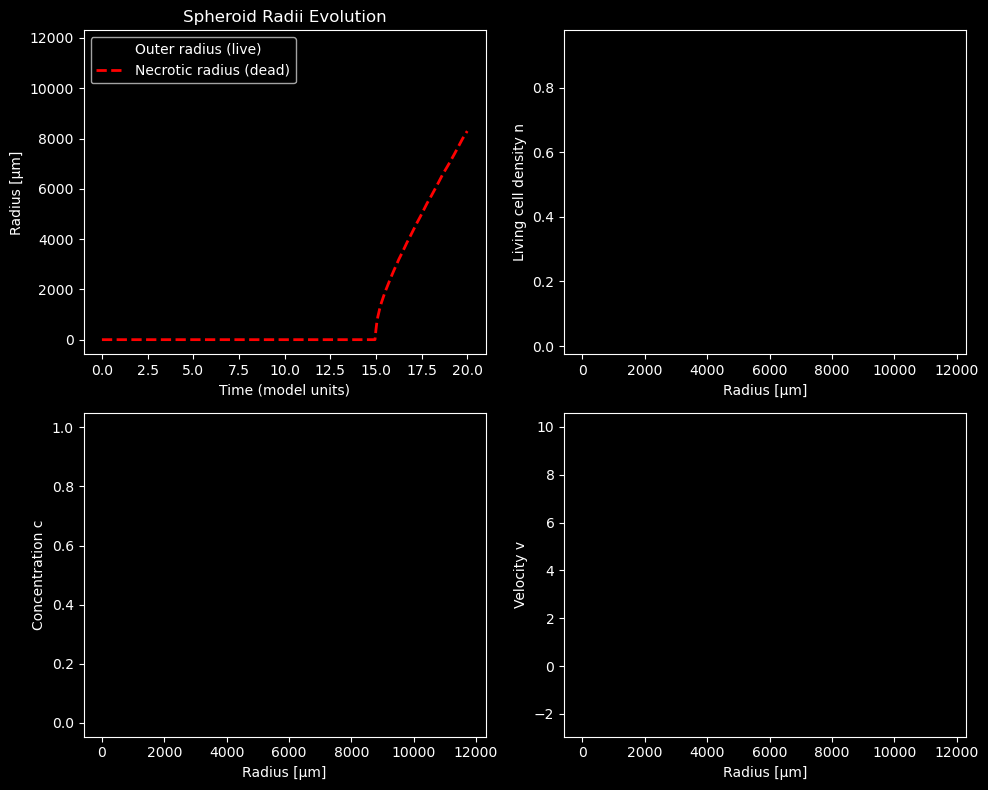


Convergence warnings: 100 time steps did not converge within 50 iterations


In [365]:
import numpy as np
t_array = np.linspace(0, 20, 100)

model = WardAndKing(l=20, dt=0.05, dxi=0.05)
radii_ = model(t_array, radii[0], plot=True)

#model = WardAndKing(l=20, dt=0.01, dxi=0.005)
#radii_ = model(t_array, plot=True)

In [10]:
%load_ext autoreload
%autoreload 2

import sys
sys.path.append('../../SpheroidPy')

from SpheroidPy.spheroid.models.ward_and_king import WardAndKing

#spheroid_series.solve(WardAndKing, 'Proliferation')

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [10]:
WardAndKing?

Init signature:
WardAndKing(
    l=50.0,
    BA=1.0,
    sigma=0.9,
    delta=0.5,
    beta=0.005,
    CC=0.1,
    CD=0.05,
    m1=1,
    m2=1,
    dxi=0.001,
    dt=0.005,
    tf=21.0,
    trecord=None,
    tol=1e-06,
    max_newton_iter=50,
    relaxation=0.8,
    check_stability=True,
)
Docstring:     
Implementation of the Ward & King (1997) mathematical model for spheroid growth.

This model simulates avascular tumor growth considering:
- Living cell density (n)
- Oxygen concentration (c) 
- Cell velocity (v)
- Spheroid radius (l)

The model uses a moving boundary formulation and accounts for:
- Cell proliferation (mitosis) dependent on oxygen availability
- Cell death dependent on oxygen availability
- Oxygen diffusion and consumption
- Internal pressure-driven cell movement
Init docstring:
Initialize the Ward & King model with given parameters.

Args:
    dxi (float): Spatial step size in transformed coordinates
    dt (float): Time step size
    tf (float): Final simulation tim

Time: 10.000, Iterations: 8: 100%|██████████| 1000/1000 [00:23<00:00, 43.32it/s]


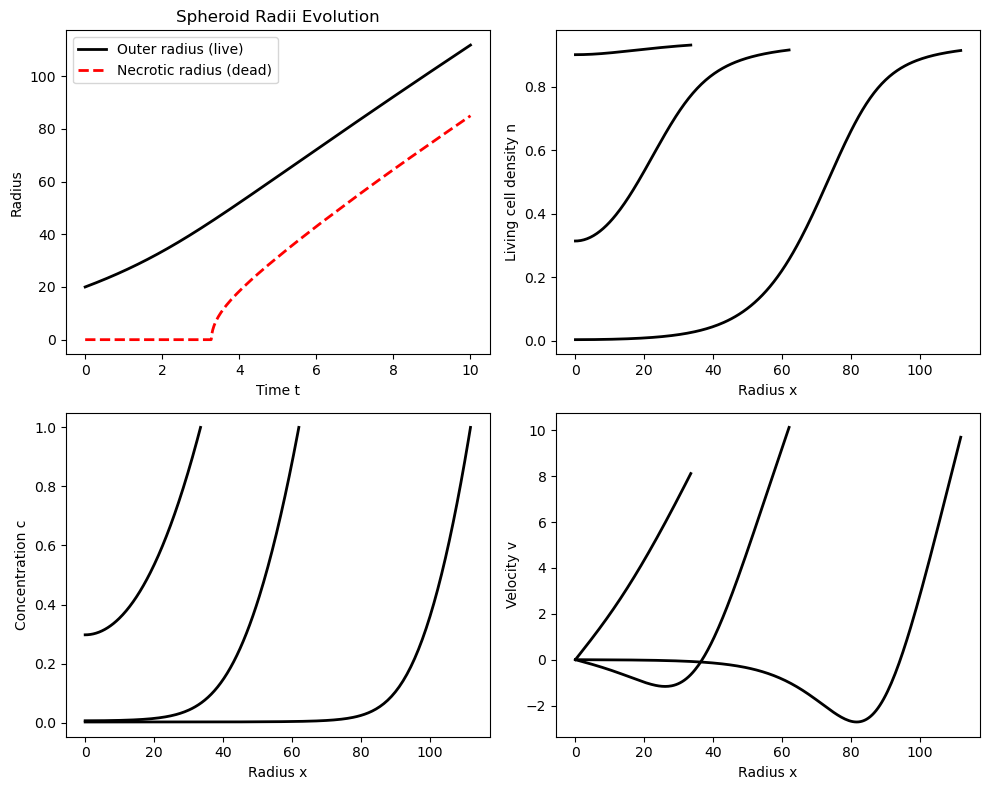


Simulation completed successfully without convergence or stability issues.


In [26]:
# Standard (mit allen Verbesserungen)
model = WardAndKing(l=20, tf=10.0, dt=0.01, dxi=0.005)
model.solve()

Time: 10.000, Iterations: 50: 100%|██████████| 200/200 [00:01<00:00, 128.17it/s]


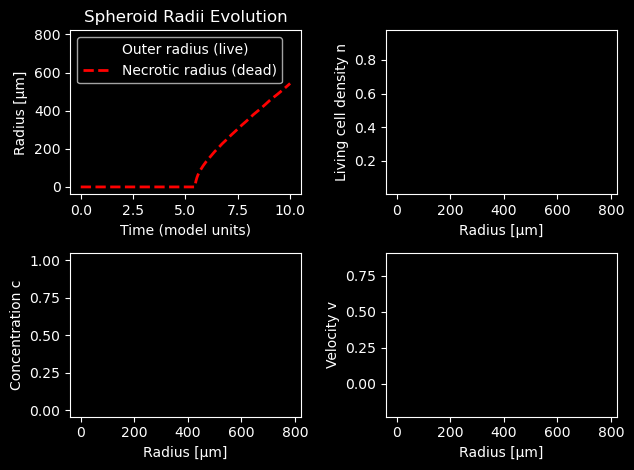


Convergence warnings: 115 time steps did not converge within 50 iterations


In [363]:
import numpy as np
t_array = np.linspace(0, 10, 100)
radii_ = model(t_array, R0=100, plot=True, beta=0.7)

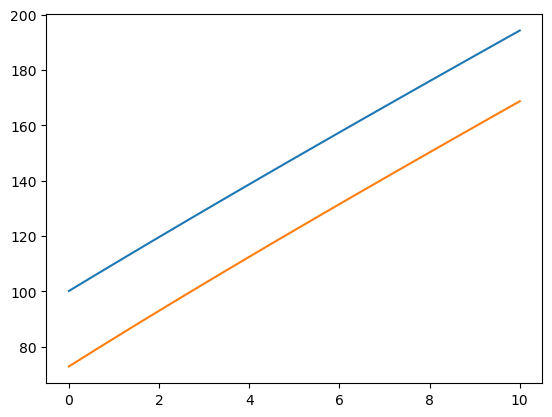

In [173]:
plt.plot(t_array, radii[:100])
plt.plot(t_array, radii[100:])

## __SpheroidCollection:__ Managing Sets of multiple SpheroidSeries
<img src="../docs/source/_images/example_SpheroidCollection.png" width="500em" align="right" style="margin-left: 50px; margin-bottom: 25px; margin-top: 10px;" />

If there are available multiple replicates, i.e. in a technical or biological sense, it often proves useful being able to combine them into one instance, so that (statistical) analyses can be streamlined and measures easily compared for different `SpheroidSeries`. Therefore, it is possible to merge multiple `SpheroidSeries` into one instance of the `SpheroidCollection`.

#### __Creating `SpheroidCollection`:__
In the following example we show this for three technical replicate Wells B5, C5, D5, which have been seeded under the same conditions and have been recorded at the same timepoints. First we have to  create `SpheroidSeries` for the three wells - similarly as shown before - and save them in an empty list:

In [24]:
spheroidseries_list = []
for well_name in ['B5', 'C5', 'D5']:
    spheroid_series = SpheroidSeries(name=f'Well {well_name}')
    
    for day in range(10,26,2):
        date_time = datetime.strptime(f'2025y05m{day}d_18h00m', '%Yy%mm%dd_%Hh%Mm')
        path_pc=f'example_data/PhaseContrast/HCT116_SpheroidProliferation_PhaseContrast_raw_{well_name}_1_2025y05m{day}d_18h00m.tif'          #PhaseContrast
        path_green=f'example_data/FluorescenceGreen/HCT116_SpheroidProliferation_fluorescence_green_{well_name}_1_2025y05m{day}d_18h00m.tif'  #green Fluorescence
        path_red=f'example_data/FluorescenceRed/HCT116_SpheroidProliferation_fluorescence_red_{well_name}_1_2025y05m{day}d_18h00m.tif'        #red Fluorescence

        # create a SpheroidImage and add to SpheroidSeries
        my_spheroid = SpheroidImage(brightfield = path_pc, 
                                    fluorescence_green = path_green, 
                                    fluorescence_red = path_red, 
                                    image_size = (1700,1270))
        spheroid_series.add_spheroid_image(my_spheroid, date_time)
        
    spheroidseries_list.append(spheroid_series) # add to our list

Now we can specify a `SpheroidCollection` based on our list of `SpheroidSeries` objects

In [26]:
from SpheroidPy.spheroid import SpheroidCollection, SpheroidSeries, SpheroidImage   # import the class
spheroid_collection = SpheroidCollection(name='HCT116_800K_cells', spheroid_list=spheroidseries_list)

TODO: Visualise `SpheroidCollection` similar to Series

In [35]:
spheroid_collection.show()

#### __Basic Usage:__
Text

In [15]:
spheroid_collection.segmentation(methods=[('thresholding', 'fluorescence_green'),('ai', 'brightfield')])

Processing segmentation: 100%|██████████| 3/3 [00:09<00:00,  3.17s/it]


Segmentation complete for collection 'HCT116_800K_cells':
Successfully segmented 23/23 images across 3 series


In [62]:
#spheroid_collection.spheroid_series[0].time_period('Proliferation', start_time='2025-05-14 18:00:00', end_time='2025-05-24 18:00:00')
#spheroid_collection.spheroid_series[0].functional_radius_series(channels='red', plot=True)
spheroid_series=spheroid_collection.spheroid_series[1]
for sp in list(spheroid_series.spheroid_image_dict.values()):
    sp.analysis_results = {}

/Users/cedric/Documents/Labor/SpheroidPy/examples/../../SpheroidPy/SpheroidPy/utils/fluorescence_analysis.py:21: RuntimeWarning: overflow encountered in exp
  return C + 1.0 / (1.0 + np.exp((r - r0) / s))


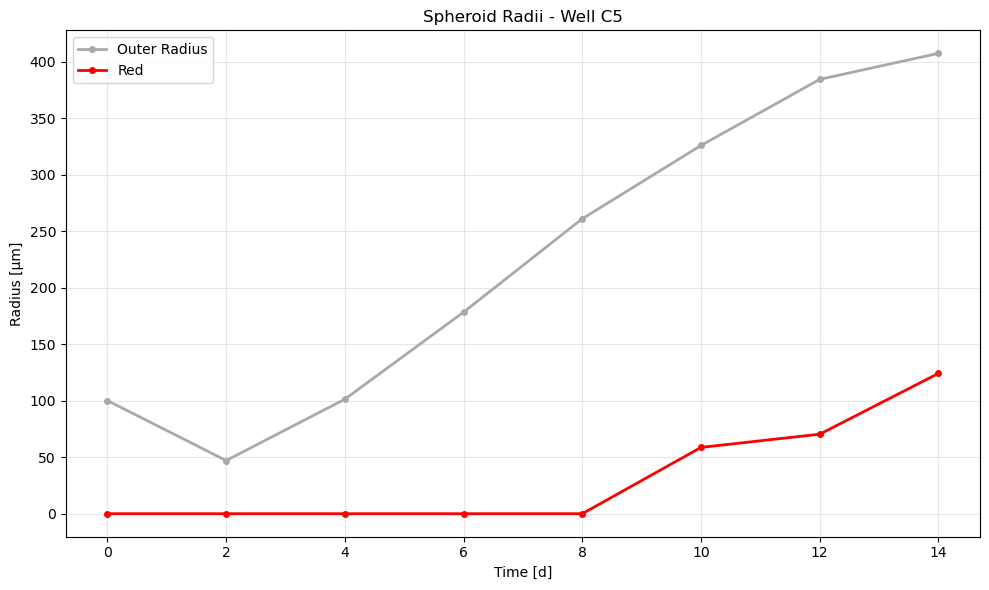

{'time': [0.0, 2.0, 4.0, 6.0, 8.0, 10.0, 12.0, 14.0],
 'outer_radius': [100.07403595866892,
  47.01550207177687,
  101.31349590668083,
  178.31413855457578,
  260.94354245283085,
  325.7614117421037,
  384.19942601961964,
  407.2192404468897],
 'functional_radius': {'red': [4.851962034516927e-17,
   2.3e-322,
   5e-322,
   3.7926967299846214e-22,
   5.048283008306501e-15,
   58.64445535186103,
   70.34542028430879,
   124.11424837880404]},
 'fit_quality': {'red': [0.406714587991556,
   -1.0321866343528368,
   -3.870848282810895,
   -0.6639923468618527,
   0.8163158406081286,
   0.9150848395041016,
   0.9019482746126868,
   0.9720555028759492]}}

In [64]:
spheroid_collection.spheroid_series[1].functional_radius_series(channels='red', plot=True, increasing=False)

# Test-Zeug

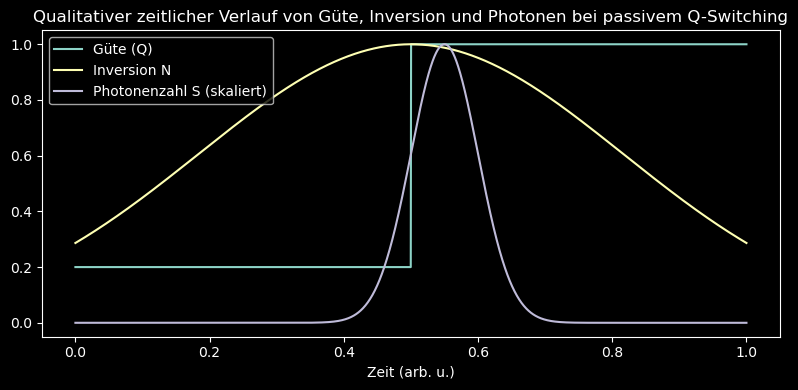

In [389]:
import numpy as np
import matplotlib.pyplot as plt

t = np.linspace(0, 1, 2000)

# Beispielhafte qualitative Kurven (keine physikalischen Werte!)
Q = 0.2 + 0.8 * (t > 0.5)               # Güte springt bei t=0.5 um
N = np.exp(-5*(t-0.5)**2)               # Inversion fällt während des Pulses
S = 40*np.exp(-200*(t-0.55)**2)         # Photonenpeak kurz nach Güteöffnung

plt.figure(figsize=(8,4))
plt.plot(t, Q, label="Güte (Q)")
plt.plot(t, N, label="Inversion N")
plt.plot(t, S/np.max(S), label="Photonenzahl S (skaliert)")

plt.xlabel("Zeit (arb. u.)")
plt.legend()
plt.title("Qualitativer zeitlicher Verlauf von Güte, Inversion und Photonen bei passivem Q-Switching")
plt.tight_layout()
plt.show()


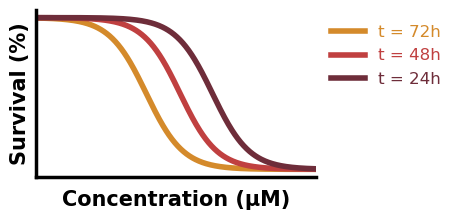

In [387]:
import matplotlib.pyplot as plt
import numpy as np

# --- 1. Stil und Setup der Figur ---

# Keinen spezifischen Stil verwenden, um Transparenz einfacher zu handhaben
# fig.patch.set_alpha(0.0) und ax.patch.set_alpha(0.0) machen den Hintergrund transparent
fig, ax = plt.subplots(figsize=(5.5, 2.3))
fig.patch.set_alpha(0.0) # Macht den Figure-Hintergrund transparent
ax.patch.set_alpha(0.0)  # Macht den Axes-Hintergrund transparent

# --- 2. Datenmodell (Sigmoidale Kurven) ---

def survival_curve(concentration, ic50, hill_slope=2.0):
    """
    Definiert die S-förmige Kurve (eine 4-Parameter-Logistik-Gleichung).
    Die Überlebensrate startet bei 100% und fällt auf 0%.
    """
    return 100 / (1 + (concentration / ic50)**hill_slope)

# Erzeuge einen Konzentrationsbereich auf einer log-Skala
# (z.B. von 0.1 bis 1000 µM)
concentrations = np.logspace(-1, 3.3, 500)

# Parameter für die drei Kurven (IC50, Farbe)
# Wir passen die IC50-Werte an, um die Verschiebung im Bild nachzubilden
curve_params = {
    't = 72h': {'ic50': 20,  'color': '#d48a2b'},  # Links (niedrigste IC50)
    't = 48h': {'ic50': 50,  'color': '#c04040'}, # Mitte
    't = 24h': {'ic50': 120, 'color': '#6e2d3a'} # Rechts (höchste IC50)
}

# --- 3. Kurven plotten ---

# Plotten jeder Kurve mit dickerer Linienstärke (linewidth)
# Jetzt mit dem 'label'-Argument für die Legende
for key, params in curve_params.items():
    survival = survival_curve(concentrations, params['ic50'])
    ax.plot(concentrations, survival, color=params['color'], linewidth=4, label=key)

# --- 4. Achsen und Beschriftungen ---

# X-Achse auf eine logarithmische Skala setzen
ax.set_xscale('log')

# Y-Achsen-Limit (damit die 100% nicht am Rand kleben)
ax.set_ylim(-5, 105)
ax.set_xlim(1,2000)

# Achsenbeschriftungen: Größer und besser lesbar (schwarz für nicht-dunklen Hintergrund)
label_color = 'black'
ax.set_xlabel('Concentration (µM)', fontsize=15, color=label_color,fontweight='semibold')
ax.set_ylabel('Survival (%)', fontsize=15, color=label_color,fontweight='bold')

# Ticks (Achsenstriche) entfernen, wie im Originalbild
ax.set_xticks([])
ax.set_yticks([])

# Achsenlinien (spines) anpassen: oben/rechts ausblenden, unten/links einfärben
ax_color = 'black' # Farbe auf Schwarz setzen
ax_thickness = 2.5 # Dicke der Achsenlinien definieren

ax.spines['bottom'].set_color(ax_color)
ax.spines['left'].set_color(ax_color)

ax.spines['bottom'].set_linewidth(ax_thickness) # Dicke anwenden
ax.spines['left'].set_linewidth(ax_thickness)   # Dicke anwenden
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# --- 5. Legende hinzufügen ---

# Erstelle die Legende oben rechts
# 'bbox_to_anchor' platziert die Legende außerhalb des Plots
# 'loc' bestimmt, welche Ecke der Legenden-Box an bbox_to_anchor anliegt (hier 'upper left' der Legende)
# 'frameon=False' entfernt den Rahmen um die Legende
# 'labelcolor' stellt sicher, dass die Labels schwarz sind
legend = ax.legend(bbox_to_anchor=(1.0, 1.0), loc='upper left', frameon=False, fontsize=12, labelcolor='black')

# Setze die Farbe der Texte in der Legende basierend auf der Kurvenfarbe
# Da `labelcolor='black'` standardmäßig die Labels schwarz macht, müssen wir dies manuell überschreiben.
# Dies erfordert den Zugriff auf die `texts` Objekte der Legende.
for text, key in zip(legend.get_texts(), curve_params.keys()):
    text.set_color(curve_params[key]['color'])
    text.set_text(key) # Sicherstellen, dass der Text korrekt ist, falls key im dict anders ist als label im plot

# --- 6. Plot anzeigen ---
plt.tight_layout(rect=[0, 0, 0.85, 1]) # rect passt den Plotbereich an, um Platz für die Legende zu schaffen
plt.savefig('kill_curve.png', transparent=True, dpi=300) # Speichern mit Transparenz und höherer Auflösung

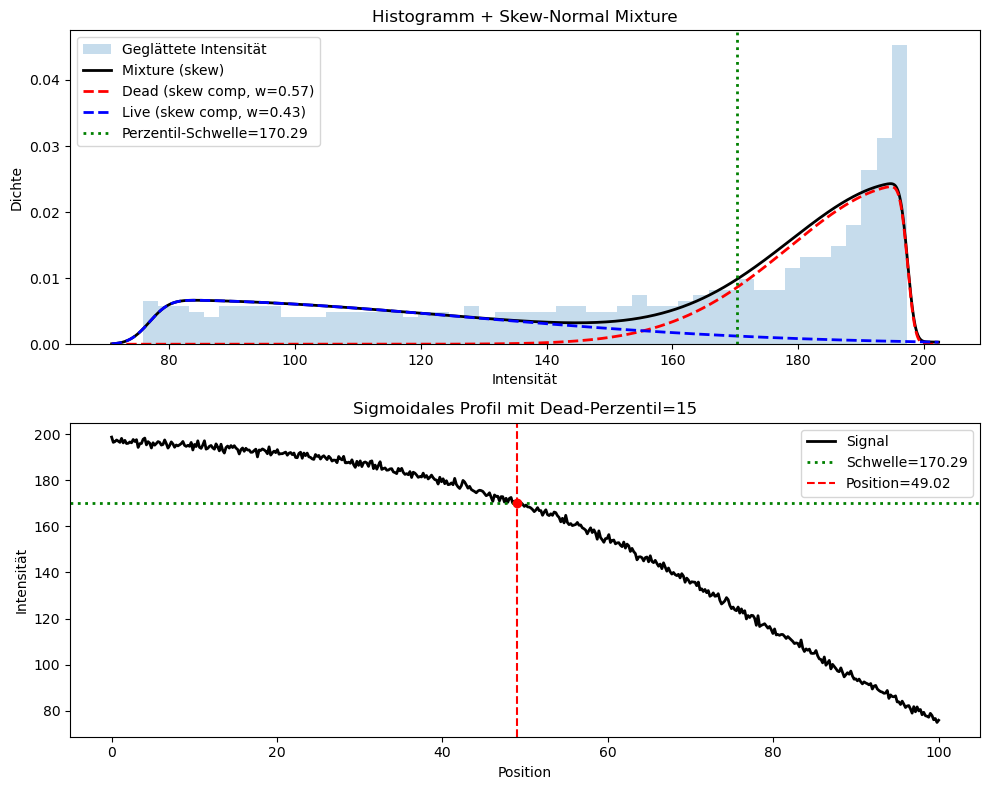

Perzentil-basierte Schwelle: 170.29, Position im Profil: 49.02


In [148]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import skewnorm
from scipy.optimize import minimize
from scipy.signal import savgol_filter

def percentile_threshold(intensity_profile, x_pos=None, dead_percentile=5, plot=True,
                         min_live_weight=0.05, min_loc_diff=None, n_restarts=8, random_state=0):
    """
    Robustere Version: Perzentil-basierte Schwellenbestimmung aus Skew-Normal Mixture,
    mit Penalties, Bounds und Restarts, um Mixture-Collapse zu verhindern.

    Neue Parameter
    --------------
    min_live_weight : float
        Minimaler Anteil (Gewicht) der Live-Komponente (z.B. 0.05 = 5%).
    min_loc_diff : float or None
        Minimale Differenz der Locations (dead_loc - live_loc). Wenn None: verwendet ~std(X)/4.
    n_restarts : int
        Anzahl der Optimierungs-Restarts (verschiedene Initialisierung).
    random_state : int
        Seed für reproducibility.
    """
    rng = np.random.default_rng(random_state)

    intensity_profile = np.asarray(intensity_profile)
    if x_pos is None:
        x_pos = np.arange(len(intensity_profile))
    x_pos = np.asarray(x_pos)

    # Glätten
    # Window length must be odd and <= len(intensity_profile)
    wl = min(31, len(intensity_profile) if len(intensity_profile)%2==1 else len(intensity_profile)-1)
    if wl < 3:
        intensity = intensity_profile.copy()
    else:
        intensity = savgol_filter(intensity_profile, window_length=wl, polyorder=2)
    X = intensity.ravel()

    if min_loc_diff is None:
        min_loc_diff = max(np.std(X) / 4.0, 1e-2)

    # --- NegLogLikelihood mit Penalties ---
    def mixture_negloglik(params, data):
        a, loc1, log_s1, sh1, loc2, log_s2, sh2 = params
        # weights via logistic (numerically stable-ish)
        w1 = 1 / (1 + np.exp(-a))
        w2 = 1 - w1
        s1 = np.exp(log_s1)
        s2 = np.exp(log_s2)

        # avoid degenerate scales
        if s1 <= 1e-6 or s2 <= 1e-6:
            return 1e12

        # pdfs
        pdf1 = skewnorm.pdf(data, a=sh1, loc=loc1, scale=s1) + 1e-300
        pdf2 = skewnorm.pdf(data, a=sh2, loc=loc2, scale=s2) + 1e-300

        mixture_pdf = w1*pdf1 + w2*pdf2 + 1e-300
        neglog = -np.sum(np.log(mixture_pdf))

        # identify dead/live by location: dead = higher loc
        if loc1 > loc2:
            dead_loc = loc1; live_loc = loc2
            dead_w = w1; live_w = w2
        else:
            dead_loc = loc2; live_loc = loc1
            dead_w = w2; live_w = w1

        # Penalty 1: ensure dead_loc sufficiently > live_loc
        loc_diff = dead_loc - live_loc
        if loc_diff < min_loc_diff:
            # quadratic penalty
            neglog += 1e4 * (min_loc_diff - loc_diff)**2

        # Penalty 2: ensure live component has at least min_live_weight
        if live_w < min_live_weight:
            neglog += 1e6 * (min_live_weight - live_w)**2

        # Optional: penalize extremely large skew magnitudes (numerical stability)
        if abs(sh1) > 40 or abs(sh2) > 40:
            neglog += 1e6

        return neglog

    # --- Bounds for parameters (for L-BFGS-B) ---
    # a: unconstrained in principle, but limit to avoid extreme weights numerically
    a_bounds = (-15, 15)
    # loc bounds: within data +/- margin
    data_min, data_max = np.min(X), np.max(X)
    loc_bounds = (data_min - 0.5*(data_max-data_min), data_max + 0.5*(data_max-data_min))
    # log scale bounds
    log_s_bounds = (np.log(np.maximum(np.std(X)/1000.0, 1e-6)), np.log(np.maximum(np.std(X)*5.0, 1e-1)))
    # skew bounds
    sh_bounds = (-20, 20)

    bounds = [
        a_bounds,
        loc_bounds, log_s_bounds, sh_bounds,
        loc_bounds, log_s_bounds, sh_bounds
    ]

    # --- multiple restarts with different initials ---
    best_res = None
    best_fun = np.inf

    # typische Quantile für Initialisierung
    q10, q20, q25, q30, q50, q70, q75, q80, q90 = np.percentile(X, [10,20,25,30,50,70,75,80,90])
    stdX = np.std(X) if np.std(X)>0 else 1.0

    init_candidates = [
        # strong separation
        [0.0, q75, np.log(stdX/2), 5.0, q25, np.log(stdX/2), -5.0]
    ]


    # pad with random inits
    for i in range(max(n_restarts, len(init_candidates))):
        if i < len(init_candidates):
            init = np.array(init_candidates[i], dtype=float)
        else:
            # random perturbation around quantiles
            loc_high = q75 + rng.normal(0, stdX*0.1)
            loc_low = q25 + rng.normal(0, stdX*0.1)
            init = np.array([rng.normal(0,1),
                             loc_high,
                             np.log(np.abs(rng.normal(stdX/2, stdX*0.2))+1e-3),
                             rng.normal(3.0, 2.0),
                             loc_low,
                             np.log(np.abs(rng.normal(stdX/2, stdX*0.2))+1e-3),
                             rng.normal(-3.0, 2.0)], dtype=float)

        try:
            res = minimize(mixture_negloglik, x0=init, args=(X,), method='L-BFGS-B',
                           bounds=bounds, options={'maxiter':2000, 'ftol':1e-9})
        except Exception:
            continue

        if res.success and res.fun < best_fun:
            best_fun = res.fun
            best_res = res
        else:
            # keep best even if not success but lower fun
            if res.fun < best_fun:
                best_fun = res.fun
                best_res = res

    if best_res is None:
        raise RuntimeError("Mixture fit failed in all restarts.")

    a, loc1, log_s1, sh1, loc2, log_s2, sh2 = best_res.x
    w1 = 1 / (1 + np.exp(-a))
    w2 = 1 - w1
    s1 = np.exp(log_s1)
    s2 = np.exp(log_s2)

    # Sortieren: Dead = hohe Intensität
    if loc1 > loc2:
        dead_loc, dead_s, dead_sh, dead_w = loc1, s1, sh1, w1
        live_loc, live_s, live_sh, live_w = loc2, s2, sh2, w2
    else:
        dead_loc, dead_s, dead_sh, dead_w = loc2, s2, sh2, w2
        live_loc, live_s, live_sh, live_w = loc1, s1, sh1, w1

    # Safety: if live weight < min_live_weight after all, force min by adjusting threshold logic (but we penalized above)
    # --- Simuliere Dead-Population (10000 Werte) ---
    dead_samples = skewnorm.rvs(a=dead_sh, loc=dead_loc, scale=dead_s, size=10000, random_state=random_state)

    # Schwelle = Perzentil der Dead-Population
    threshold_intensity = np.percentile(dead_samples, dead_percentile)

    # --- Bestimme Richtung des Profils und genaue Crossing-Position (interpoliert) ---
    slope = np.median(np.gradient(intensity))
    if slope < 0:  # fallendes Profil: von hoch (Dead) nach niedrig (Live)
        crossing_idx = np.where((intensity[:-1] >= threshold_intensity) &
                                (intensity[1:] < threshold_intensity))[0]
    else:  # steigendes Profil: von niedrig (Live) nach hoch (Dead)
        crossing_idx = np.where((intensity[:-1] <= threshold_intensity) &
                                (intensity[1:] > threshold_intensity))[0]

    if len(crossing_idx) > 0:
        i = crossing_idx[0]
        x1, x2 = x_pos[i], x_pos[i+1]
        y1, y2 = intensity[i], intensity[i+1]
        # guard against flat segment
        if np.isclose(y2, y1):
            threshold_position = (x1 + x2) / 2.0
        else:
            threshold_position = x1 + (threshold_intensity - y1) * (x2 - x1) / (y2 - y1)
    else:
        threshold_position = None

    # --- Optional Plot ---
    if plot:
        xs = np.linspace(np.min(X)-5, np.max(X)+5, 5000)
        pdf_dead_plot = dead_w * skewnorm.pdf(xs, a=dead_sh, loc=dead_loc, scale=dead_s)
        pdf_live_plot = live_w * skewnorm.pdf(xs, a=live_sh, loc=live_loc, scale=live_s)
        plt.figure(figsize=(10,8))

        # Histogram + PDFs
        plt.subplot(2,1,1)
        plt.hist(X, bins=50, density=True, alpha=0.25, label='Geglättete Intensität')
        plt.plot(xs, pdf_dead_plot + pdf_live_plot, 'k-', lw=2, label='Mixture (skew)')
        plt.plot(xs, pdf_dead_plot, 'r--', lw=2, label=f'Dead (skew comp, w={dead_w:.2f})')
        plt.plot(xs, pdf_live_plot, 'b--', lw=2, label=f'Live (skew comp, w={live_w:.2f})')
        plt.axvline(threshold_intensity, color='g', linestyle=':', lw=2, label=f'Perzentil-Schwelle={threshold_intensity:.2f}')
        plt.xlabel('Intensität')
        plt.ylabel('Dichte')
        plt.title('Histogramm + Skew-Normal Mixture')
        plt.legend()

        # Profil + Schwelle
        plt.subplot(2,1,2)
        plt.plot(x_pos, intensity_profile, 'k-', lw=2, label='Signal')
        if threshold_position is not None:
            plt.axhline(threshold_intensity, color='g', linestyle=':', lw=2, label=f'Schwelle={threshold_intensity:.2f}')
            plt.axvline(threshold_position, color='r', linestyle='--', lw=1.5, label=f'Position={threshold_position:.2f}')
            plt.plot(threshold_position, threshold_intensity, 'ro')
        plt.xlabel('Position')
        plt.ylabel('Intensität')
        plt.title(f'Sigmoidales Profil mit Dead-Perzentil={dead_percentile}')
        plt.legend()
        plt.tight_layout()
        plt.show()

    return threshold_intensity, threshold_position, dead_samples


# ========================
# Test / Beispiel
# ========================
if __name__ == "__main__":
    # Beispiel: simuliertes fallendes Sigmoid
    x_pos = np.linspace(0,100,500)
    def sigmoid(x, x0=80, k=-0.05, low=30, high=200):
        return low + (high-low)/(1+np.exp(-k*(x-x0)))
    intensity_profile = sigmoid(x_pos) + np.random.normal(0,1,size=x_pos.shape)

    threshold, pos, dead_samples = percentile_threshold(intensity_profile, x_pos=x_pos, dead_percentile=15)
    print(f"Perzentil-basierte Schwelle: {threshold:.2f}, Position im Profil: {pos:.2f}")

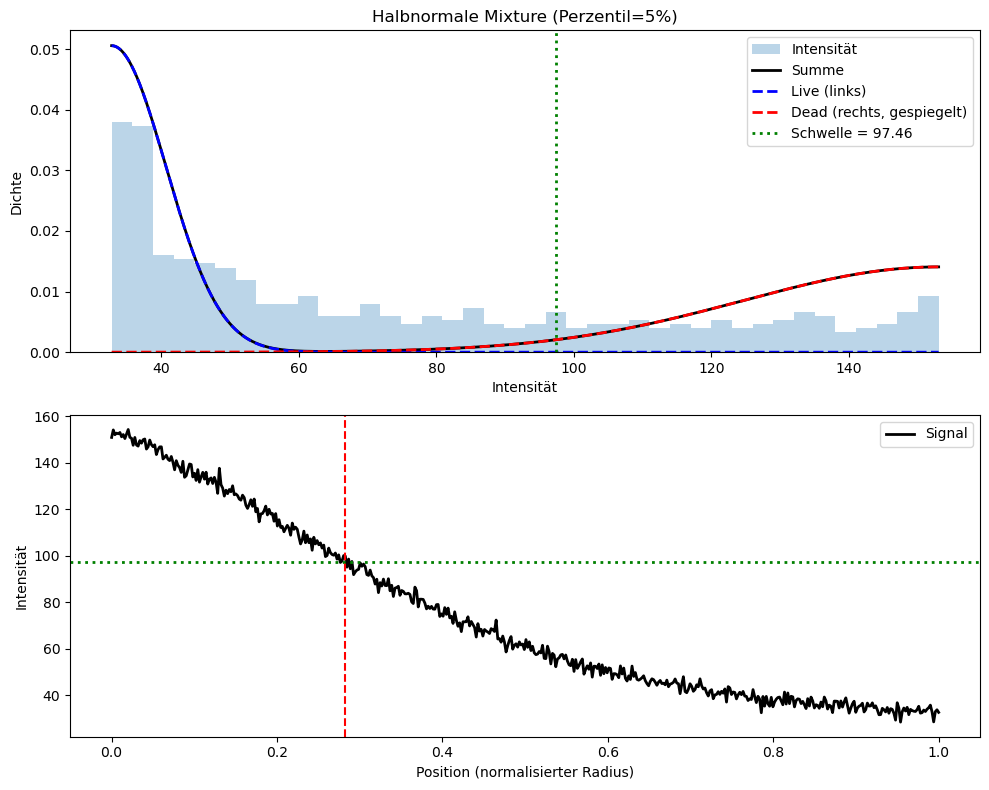

Mit Perzentil: 97.46, Position: 0.283


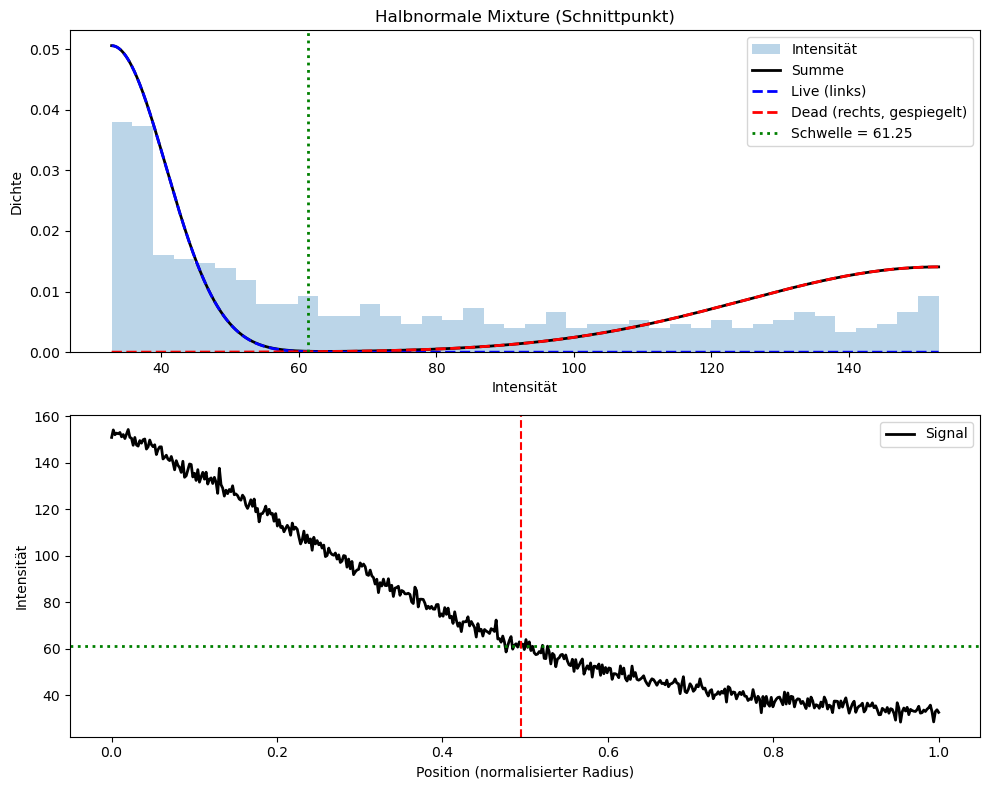

Mit Schnittpunkt: 61.25, Position: 0.495


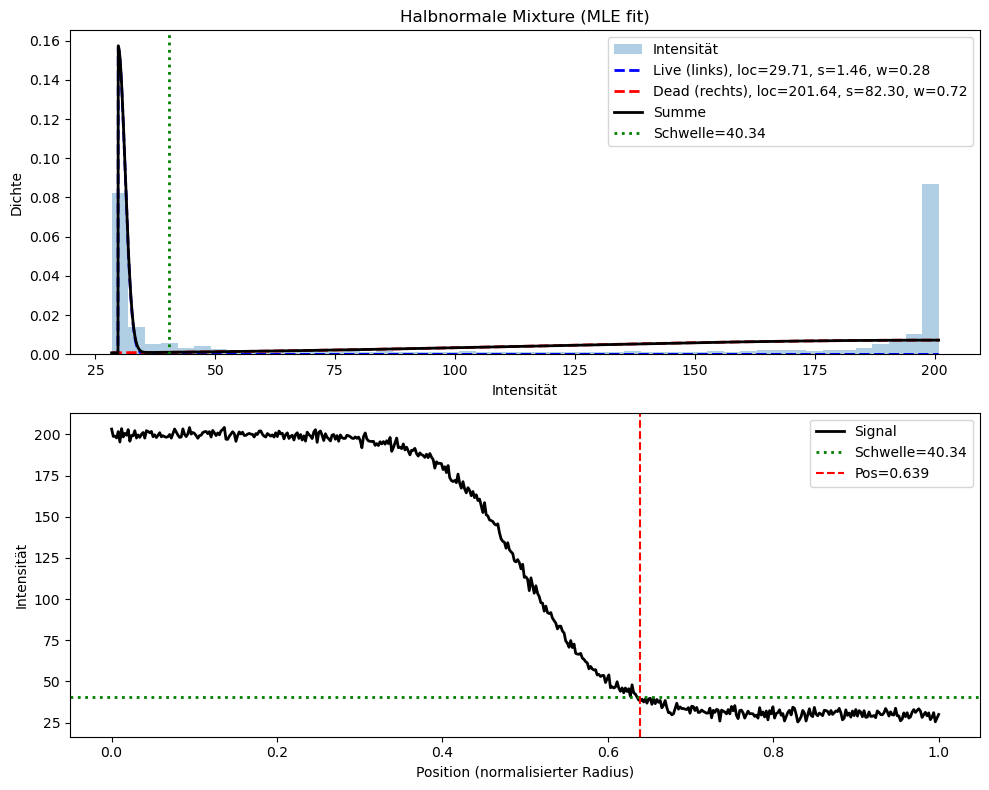

Threshold: 40.33562319559249 Position: 0.6392785571142284
Fit params: {'loc1': 29.710025716563067, 's1': 1.4585854197037136, 'loc2': 201.64023634473386, 's2': 82.29978429271742, 'w': 0.28266853311168805, 'nll': 2235.0539209704284, 'opt':   message: ABNORMAL: 
  success: False
   status: 2
      fun: 2235.0539209704284
        x: [ 3.775e-01  2.971e+01  4.410e+00  2.016e+02 -9.313e-01]
      nit: 10
      jac: [-1.868e+01 -8.401e+01  3.067e+01  2.490e+00 -1.327e+01]
     nfev: 660
     njev: 110
 hess_inv: <5x5 LbfgsInvHessProduct with dtype=float64>}


In [81]:
#!/usr/bin/env python3
# -*- coding: utf-8 -*-
"""
Halbnormale Mixture mit korrekter Skalierung und Orientierung
- Live: linksseitig, fällt nach rechts
- Dead: rechtsseitig, fällt nach links
- Schwelle per Perzentil oder Schnittpunkt
"""

import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import halfnorm
from scipy.signal import savgol_filter
from scipy.optimize import minimize_scalar


def percentile_threshold(intensity_profile, x_pos=None, dead_percentile=None, plot=True):
    intensity_profile = np.asarray(intensity_profile)
    if x_pos is None:
        x_pos = np.arange(len(intensity_profile))
    x_pos = np.asarray(x_pos)

    # Glätten
    intensity = savgol_filter(intensity_profile, 31, 2)
    X = intensity.ravel()

    rising = np.mean(X[-10:]) > np.mean(X[:10])
    median = np.median(X)
    live_vals = X[X < median]
    dead_vals = X[X >= median]

    live_loc = np.min(X)
    dead_loc = np.max(X)
    live_scale = np.std(live_vals)
    dead_scale = np.std(dead_vals)

    xs = np.linspace(np.min(X), np.max(X), 2000)

    # Live (links)
    pdf_live = halfnorm.pdf(xs - live_loc, scale=live_scale)
    pdf_live /= np.trapz(pdf_live, xs)

    # Dead (rechts) → gespiegelt
    pdf_dead_raw = halfnorm.pdf(xs - xs[0], scale=dead_scale)
    pdf_dead = pdf_dead_raw[::-1]  # nach links gedreht
    pdf_dead /= np.trapz(pdf_dead, xs)

    # Mischungsgewichte
    w_live = len(live_vals) / len(X)
    w_dead = len(dead_vals) / len(X)

    pdf_live *= w_live
    pdf_dead *= w_dead
    pdf_sum = pdf_live + pdf_dead

    # Schwelle bestimmen
    if dead_percentile is not None:
        # Perzentil von rechter (Dead-)Verteilung
        thr_offset = halfnorm.ppf((100 - dead_percentile) / 100, scale=dead_scale)
        threshold_intensity = dead_loc - thr_offset
    else:
        # Schnittpunkt numerisch
        def diff(x):
            return abs(np.interp(x, xs, pdf_live) - np.interp(x, xs, pdf_dead))
        res = minimize_scalar(diff, bounds=(xs[0], xs[-1]), method="bounded")
        threshold_intensity = res.x

    # Schwellenposition
    if rising:
        idx = np.where(intensity >= threshold_intensity)[0]
    else:
        idx = np.where(intensity <= threshold_intensity)[0]
    threshold_position = x_pos[idx[0]] if len(idx) > 0 else None

    if plot:
        plt.figure(figsize=(10, 8))

        # Histogram + PDFs
        plt.subplot(2, 1, 1)
        plt.hist(X, bins=40, density=True, alpha=0.3, label="Intensität")
        plt.plot(xs, pdf_sum, "k-", lw=2, label="Summe")
        plt.plot(xs, pdf_live, "b--", lw=2, label="Live (links)")
        plt.plot(xs, pdf_dead, "r--", lw=2, label="Dead (rechts, gespiegelt)")
        plt.axvline(threshold_intensity, color="g", linestyle=":", lw=2,
                    label=f"Schwelle = {threshold_intensity:.2f}")
        plt.xlabel("Intensität")
        plt.ylabel("Dichte")
        title = f"Halbnormale Mixture ({'Schnittpunkt' if dead_percentile is None else f'Perzentil={dead_percentile}%'})"
        plt.title(title)
        plt.legend()

        # Signalprofil
        plt.subplot(2, 1, 2)
        plt.plot(x_pos, intensity_profile, "k-", lw=2, label="Signal")
        plt.axhline(threshold_intensity, color="g", linestyle=":", lw=2)
        if threshold_position is not None:
            plt.axvline(threshold_position, color="r", linestyle="--", lw=1.5)
        plt.xlabel("Position (normalisierter Radius)")
        plt.ylabel("Intensität")
        plt.legend()
        plt.tight_layout()
        plt.show()

    return threshold_intensity, threshold_position


# === Test ===
if __name__ == "__main__":
    x_pos = np.linspace(0, 1, 500)
    def sigmoid(x, x0=0.2, k=-5, low=30, high=200):
        return low + (high - low) / (1 + np.exp(-k * (x - x0)))
    intensity_profile = sigmoid(x_pos) + np.random.normal(0, 2, size=x_pos.shape)

    thr1, pos1 = percentile_threshold(intensity_profile, x_pos, dead_percentile=5)
    print(f"Mit Perzentil: {thr1:.2f}, Position: {pos1:.3f}")

    thr2, pos2 = percentile_threshold(intensity_profile, x_pos, dead_percentile=None)
    print(f"Mit Schnittpunkt: {thr2:.2f}, Position: {pos2:.3f}")#!/usr/bin/env python3
# -*- coding: utf-8 -*-
"""
Mixture aus zwei Halbnormalen (Live links, Dead rechts gespiegelt)
Parameterschätzung per MLE (numerische Optimierung, mehrere Restarts)
"""

import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import halfnorm
from scipy.signal import savgol_filter
from scipy.optimize import minimize
import math

def fit_halfnorm_mixture(X, n_restarts=8, random_seed=0):
    """
    Fit mixture: pdf(x) = w * halfnorm.pdf(x - loc1, scale=s1) + (1-w) * halfnorm.pdf(loc2 - x, scale=s2)
    where first component has peak at low values (loc1 ~ low end), second is mirrored and peaks at loc2 ~ high end.
    Returns best parameters: dict with keys loc1,s1,loc2,s2,w and negative log-likelihood.
    """
    X = np.asarray(X)
    eps = 1e-12

    xmin, xmax = np.min(X), np.max(X)
    rng = np.random.default_rng(random_seed)

    # helper: negative log-likelihood for given params
    def negloglik(params):
        # params: [log_s1, loc1, log_s2, loc2, logit_w]
        log_s1, loc1, log_s2, loc2, logit_w = params
        s1 = np.exp(log_s1)
        s2 = np.exp(log_s2)
        w = 1.0 / (1.0 + np.exp(-logit_w))
        # compute component PDFs for data points
        # comp1 nonzero for x >= loc1, comp2 nonzero for x <= loc2
        p1 = halfnorm.pdf(X - loc1, scale=s1)
        p2 = halfnorm.pdf(loc2 - X, scale=s2)
        mix = w * p1 + (1.0 - w) * p2 + eps
        return -np.sum(np.log(mix))

    best = None
    for r in range(n_restarts):
        # Initialize: locs around edges but jittered, scales from MAD or std, weight random
        loc1_init = xmin + 0.02*(xmax-xmin) + 0.05*(xmax-xmin)*rng.standard_normal()
        loc2_init = xmax - 0.02*(xmax-xmin) + 0.05*(xmax-xmin)*rng.standard_normal()
        # robust scale est: MAD
        mad = np.median(np.abs(X - np.median(X))) + 1e-6
        s_init = max(np.std(X)/4, mad)
        s1_init = s_init * (0.8 + 0.4*rng.random())
        s2_init = s_init * (0.8 + 0.4*rng.random())
        w_init = 0.5 + 0.2*(rng.random()-0.5)

        x0 = [math.log(s1_init), loc1_init, math.log(s2_init), loc2_init, math.log(w_init/(1-w_init))]

        # Bounds: scales positive, loc inside [xmin,xmax], logit_w free
        bounds = [
            (math.log(1e-6), math.log(xmax-xmin+1e-3)),     # log_s1
            (xmin - 0.1*(xmax-xmin), xmin + 0.5*(xmax-xmin)), # loc1 (allow some movement)
            (math.log(1e-6), math.log(xmax-xmin+1e-3)),     # log_s2
            (xmin + 0.5*(xmax-xmin), xmax + 0.1*(xmax-xmin)), # loc2
            (None, None)                                    # logit_w
        ]

        res = minimize(negloglik, x0=x0, bounds=bounds, method='L-BFGS-B',
                       options={'maxiter':2000})
        if not res.success:
            # try again without bounds (fallback)
            pass

        nll = res.fun
        if (best is None) or (nll < best['nll']):
            s1 = float(np.exp(res.x[0]))
            loc1 = float(res.x[1])
            s2 = float(np.exp(res.x[2]))
            loc2 = float(res.x[3])
            w = float(1/(1+np.exp(-res.x[4])))
            best = dict(loc1=loc1, s1=s1, loc2=loc2, s2=s2, w=w, nll=float(nll), opt=res)

    return best

def percentile_threshold_mle(intensity_profile, x_pos=None, dead_percentile=None, plot=True, n_restarts=8):
    """
    Fit MLE mixture of two halfnorms and compute threshold (perzentil auf Dead or intersection).
    Returns threshold intensity, threshold position, and fitted params.
    """
    intensity_profile = np.asarray(intensity_profile)
    if x_pos is None:
        x_pos = np.arange(len(intensity_profile))
    x_pos = np.asarray(x_pos)

    # Smooth the profile a bit for stable fitting
    intensity = savgol_filter(intensity_profile, window_length=31 if len(intensity_profile)>31 else (len(intensity_profile)//2*2+1), polyorder=2)
    X = intensity.ravel()

    # Fit mixture
    fit = fit_halfnorm_mixture(X, n_restarts=n_restarts, random_seed=42)

    loc1, s1 = fit['loc1'], fit['s1']
    loc2, s2 = fit['loc2'], fit['s2']
    w = fit['w']

    # prepare xs for plotting and numeric intersection
    xs = np.linspace(np.min(X), np.max(X), 3000)
    pdf1 = halfnorm.pdf(xs - loc1, scale=s1)
    pdf2 = halfnorm.pdf(loc2 - xs, scale=s2)
    # normalize each to area=1 then apply weights -> so histogram (density=True) is comparable
    pdf1 /= np.trapz(pdf1, xs)
    pdf2 /= np.trapz(pdf2, xs)
    pdf1 *= w
    pdf2 *= (1.0 - w)
    pdf_sum = pdf1 + pdf2

    # threshold: perzentil on Dead (right) or intersection
    if dead_percentile is not None:
        # compute percentile of the dead component (right), dead is mirrored around loc2
        # For dead: variable y = loc2 - x >= 0 has halfnorm distribution with scale s2.
        # We want x such that P_dead(X >= x) = p -> equivalently y <= loc2 - x at percentile
        # halfnorm.ppf gives quantile in y-space, so:
        q = halfnorm.ppf((100 - dead_percentile) / 100.0, scale=s2)  # this is y quantile
        threshold_intensity = loc2 - q
    else:
        # find x where weighted pdfs cross: solve pdf1(x) = pdf2(x)
        # do numeric root of (pdf1 - pdf2)
        diffs = np.abs(pdf1 - pdf2)
        idx = np.argmin(diffs)
        threshold_intensity = xs[idx]

    # find position in profile
    rising = np.mean(X[-max(1,min(10,len(X))):]) > np.mean(X[:max(1,min(10,len(X)))])
    if rising:
        idxs = np.where(intensity >= threshold_intensity)[0]
    else:
        idxs = np.where(intensity <= threshold_intensity)[0]
    threshold_position = x_pos[idxs[0]] if len(idxs)>0 else None

    if plot:
        plt.figure(figsize=(10,8))
        plt.subplot(2,1,1)
        plt.hist(X, bins=50, density=True, alpha=0.35, label='Intensität')
        plt.plot(xs, pdf1, 'b--', lw=2, label=f'Live (links), loc={loc1:.2f}, s={s1:.2f}, w={w:.2f}')
        plt.plot(xs, pdf2, 'r--', lw=2, label=f'Dead (rechts), loc={loc2:.2f}, s={s2:.2f}, w={1-w:.2f}')
        plt.plot(xs, pdf_sum, 'k-', lw=2, label='Summe')
        plt.axvline(threshold_intensity, color='g', linestyle=':', lw=2, label=f'Schwelle={threshold_intensity:.2f}')
        plt.xlabel('Intensität')
        plt.ylabel('Dichte')
        plt.title(f'Halbnormale Mixture (MLE fit)')
        plt.legend(loc='upper right')

        plt.subplot(2,1,2)
        plt.plot(x_pos, intensity_profile, 'k-', lw=2, label='Signal')
        plt.axhline(threshold_intensity, color='g', linestyle=':', lw=2, label=f'Schwelle={threshold_intensity:.2f}')
        if threshold_position is not None:
            plt.axvline(threshold_position, color='r', linestyle='--', lw=1.5, label=f'Pos={threshold_position:.3f}')
        plt.xlabel('Position (normalisierter Radius)')
        plt.ylabel('Intensität')
        plt.legend()
        plt.tight_layout()
        plt.show()

    return threshold_intensity, threshold_position, fit

# ================= Example / Test =================
if __name__ == "__main__":
    import matplotlib
    np.random.seed(1)
    x_pos = np.linspace(0,1,500)
    def sigmoid(x, x0=0.5, k=-20, low=30, high=200):
        return low + (high-low)/(1+np.exp(-k*(x-x0)))
    intensity_profile = sigmoid(x_pos) + np.random.normal(0,2,size=x_pos.shape)

    thr, pos, params = percentile_threshold_mle(intensity_profile, x_pos=x_pos, dead_percentile=5, plot=True, n_restarts=12)
    print("Threshold:", thr, "Position:", pos)
    print("Fit params:", params)

    


sample: 100%|██████████| 2000/2000 [00:02<00:00, 718.11it/s, 7 steps of size 4.28e-01. acc. prob=0.89]  


Posterior means (loc_dead, loc_live): 163.14487 33.261738
Posterior scales (dead, live): 43.006638 26.320984
Posterior skews (dead, live): -5.1229815 10.5540085
Posterior weights (dead, live): [0.43586263 0.5641373 ]
Schwelle (mittleres lower 95% dead-Interval): 73.507
Mean dead interval: (73.507, 175.274)
Lower CI (2.5/97.5): [51.34081661 88.91182991]
Upper CI (2.5/97.5): [175.00745546 175.60796115]


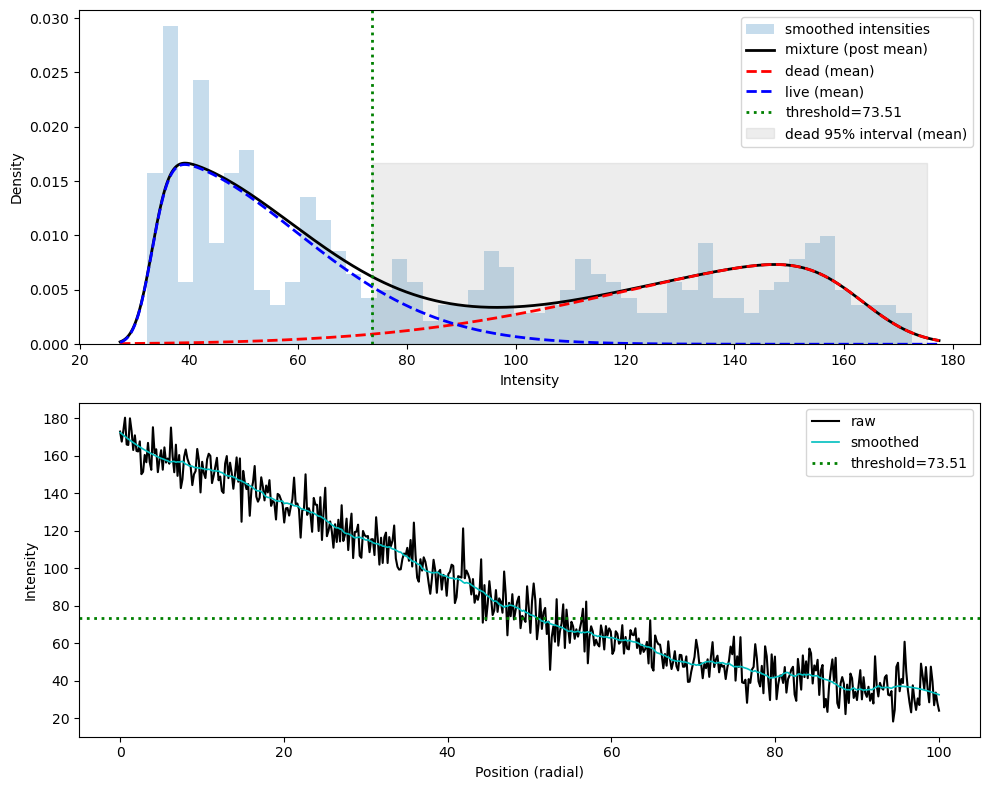

In [48]:
#!/usr/bin/env python3
# -*- coding: utf-8 -*-
"""
Überarbeitetes NumPyro-Modell für radiales PI-Intensitätsprofil
- klare Reihenfolge: w = [dead, live]
- daten-adaptive informative priors (für nicht-konfokale PI-Aufnahmen)
- Schwellenbestimmung: Perzentile der dead-Fraktion (5% außen -> 2.5/97.5)
- Hinweise: braucht jax/jaxlib + numpyro
"""

import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import savgol_filter
from scipy.stats import skewnorm
import jax.numpy as jnp
import jax
import numpyro
import numpyro.distributions as dist
from numpyro.infer import MCMC, NUTS
from jax.scipy.special import logsumexp
from jax.scipy.stats import norm

# -------------- Beispiel (wie Nutzer) --------------
np.random.seed(42)
x_pos = np.linspace(0,100,500)
def sigmoid(x, x0=30, k=-0.05, low=30, high=200):
    return low + (high-low)/(1+np.exp(-k*(x-x0)))

intensity_profile = sigmoid(x_pos) + np.random.normal(0,8,size=x_pos.shape)
intensity_smoothed = savgol_filter(intensity_profile, window_length=51, polyorder=2)
X = intensity_smoothed  # Daten für das Modell

# -------------- Hilfsfunktion: Skew-Normal Log-PDF (JAX) --------------
def skewnorm_logpdf(x, loc, scale, alpha):
    z = (x - loc) / scale
    return jnp.log(2.0 / scale) + norm.logpdf(z) + norm.logcdf(alpha * z)

# -------------- NumPyro Modell --------------
def skew_mixture_model(X):
    # Konvention: w = [dead, live]
    # Prior: eher Mehrheit live erwarten -> Dirichlet([1,9]) (aber flexibel)
    w = numpyro.sample('w', dist.Dirichlet(jnp.array([1.0, 9.0])))

    # Daten-getriebene informative Priors:
    q10 = jnp.percentile(X, 10.)
    q90 = jnp.percentile(X, 90.)
    data_std = jnp.std(X)

    # Lagepriors: dead um höhere Intensitäten (q90), live um niedrigere (q10)
    loc_dead = numpyro.sample('loc_dead', dist.Normal(q90, jnp.maximum(5.0, 0.2*data_std)))
    loc_live = numpyro.sample('loc_live', dist.Normal(q10, jnp.maximum(5.0, 0.2*data_std)))

    # Skalen: non-confocal -> breiter
    scale_dead = numpyro.sample('scale_dead', dist.HalfNormal(jnp.maximum(5.0, 0.3*data_std)))
    scale_live = numpyro.sample('scale_live', dist.HalfNormal(jnp.maximum(5.0, 0.3*data_std)))

    # Schiefe: moderate Erwartung (dead > 0, live < 0), aber breit
    skew_dead = numpyro.sample('skew_dead', dist.Normal(2.0, 3.0))
    skew_live = numpyro.sample('skew_live', dist.Normal(-2.0, 3.0))

    # Marginalisierte mixture (stabil numerisch)
    log_prob_dead = skewnorm_logpdf(X, loc_dead, scale_dead, skew_dead)
    log_prob_live = skewnorm_logpdf(X, loc_live, scale_live, skew_live)
    log_probs = jnp.stack([jnp.log(w[0]) + log_prob_dead, jnp.log(w[1]) + log_prob_live], axis=-1)
    log_sum = logsumexp(log_probs, axis=-1)
    numpyro.factor("obs", log_sum.sum())

# -------------- MCMC --------------
nuts_kernel = NUTS(skew_mixture_model)
mcmc = MCMC(nuts_kernel, num_warmup=800, num_samples=1200)  # anpassbar
mcmc.run(jax.random.PRNGKey(0), X=X)
samples = mcmc.get_samples()

# -------------- Posterior-Mittelwerte (Übersicht) --------------
loc_dead_post = np.mean(np.array(samples['loc_dead']))
loc_live_post = np.mean(np.array(samples['loc_live']))
scale_dead_post = np.mean(np.array(samples['scale_dead']))
scale_live_post = np.mean(np.array(samples['scale_live']))
skew_dead_post = np.mean(np.array(samples['skew_dead']))
skew_live_post = np.mean(np.array(samples['skew_live']))
w_post = np.mean(np.array(samples['w']), axis=0)

print("Posterior means (loc_dead, loc_live):", loc_dead_post, loc_live_post)
print("Posterior scales (dead, live):", scale_dead_post, scale_live_post)
print("Posterior skews (dead, live):", skew_dead_post, skew_live_post)
print("Posterior weights (dead, live):", w_post)

# -------------- Schwellenbestimmung via Perzentile der dead-Fraktion --------------
xs = np.linspace(np.min(X)-5, np.max(X)+5, 2000)
thresholds = []
# Für jeden Posterior-Sample: posterior_prob_dead(xs)
Nsamples = len(samples['loc_dead'])
for i in range(Nsamples):
    ld = samples['loc_dead'][i]
    sd = samples['scale_dead'][i]
    kd = samples['skew_dead'][i]
    ll = samples['loc_live'][i]
    sl = samples['scale_live'][i]
    kl = samples['skew_live'][i]
    ww = samples['w'][i]  # [dead, live]

    pdf_d = ww[0] * skewnorm.pdf(xs, a=kd, loc=ld, scale=sd)
    pdf_l = ww[1] * skewnorm.pdf(xs, a=kl, loc=ll, scale=sl)
    post_dead = pdf_d / (pdf_d + pdf_l + 1e-12)

    # Normiere post_dead über xs zu einer "Masse" (für Quantilbestimmung)
    mass = post_dead / (post_dead.sum() + 1e-12)
    cumsum = np.cumsum(mass)
    lower_idx = np.searchsorted(cumsum, 0.025)
    upper_idx = np.searchsorted(cumsum, 0.975)
    lower_x = xs[min(lower_idx, len(xs)-1)]
    upper_x = xs[min(upper_idx, len(xs)-1)]
    thresholds.append((lower_x, upper_x))

thresholds = np.array(thresholds)
lower_mean = thresholds[:,0].mean()
upper_mean = thresholds[:,1].mean()
threshold_intensity = lower_mean  # die Grenze, ab der als 'dead' interpretiert wird

print(f"Schwelle (mittleres lower 95% dead-Interval): {threshold_intensity:.3f}")
print(f"Mean dead interval: ({lower_mean:.3f}, {upper_mean:.3f})")
print("Lower CI (2.5/97.5):", np.percentile(thresholds[:,0],[2.5,97.5]))
print("Upper CI (2.5/97.5):", np.percentile(thresholds[:,1],[2.5,97.5]))

# -------------- Visualisierung --------------
plt.figure(figsize=(10,8))
plt.subplot(2,1,1)
plt.hist(X, bins=50, density=True, alpha=0.25, label='smoothed intensities')
xs_f = np.linspace(np.min(X)-5, np.max(X)+5, 1000)
pdf_dead_plot = w_post[0] * skewnorm.pdf(xs_f, a=skew_dead_post, loc=loc_dead_post, scale=scale_dead_post)
pdf_live_plot = w_post[1] * skewnorm.pdf(xs_f, a=skew_live_post, loc=loc_live_post, scale=scale_live_post)
plt.plot(xs_f, pdf_dead_plot + pdf_live_plot, 'k-', lw=2, label='mixture (post mean)')
plt.plot(xs_f, pdf_dead_plot, 'r--', lw=2, label='dead (mean)')
plt.plot(xs_f, pdf_live_plot, 'b--', lw=2, label='live (mean)')
plt.axvline(threshold_intensity, color='g', linestyle=':', lw=2, label=f'threshold={threshold_intensity:.2f}')
plt.fill_betweenx([0, np.max(pdf_dead_plot+pdf_live_plot)], lower_mean, upper_mean, color='gray', alpha=0.14, label='dead 95% interval (mean)')
plt.legend()
plt.xlabel('Intensity')
plt.ylabel('Density')

plt.subplot(2,1,2)
plt.plot(x_pos, intensity_profile, 'k-', lw=1.5, label='raw')
plt.plot(x_pos, X, 'c-', lw=1.2, label='smoothed')
plt.axhline(threshold_intensity, color='g', linestyle=':', lw=2, label=f'threshold={threshold_intensity:.2f}')
plt.xlabel('Position (radial)')
plt.ylabel('Intensity')
plt.legend()
plt.tight_layout()
plt.show()


sample: 100%|██████████| 2000/2000 [00:02<00:00, 680.61it/s, 15 steps of size 4.07e-01. acc. prob=0.91] 


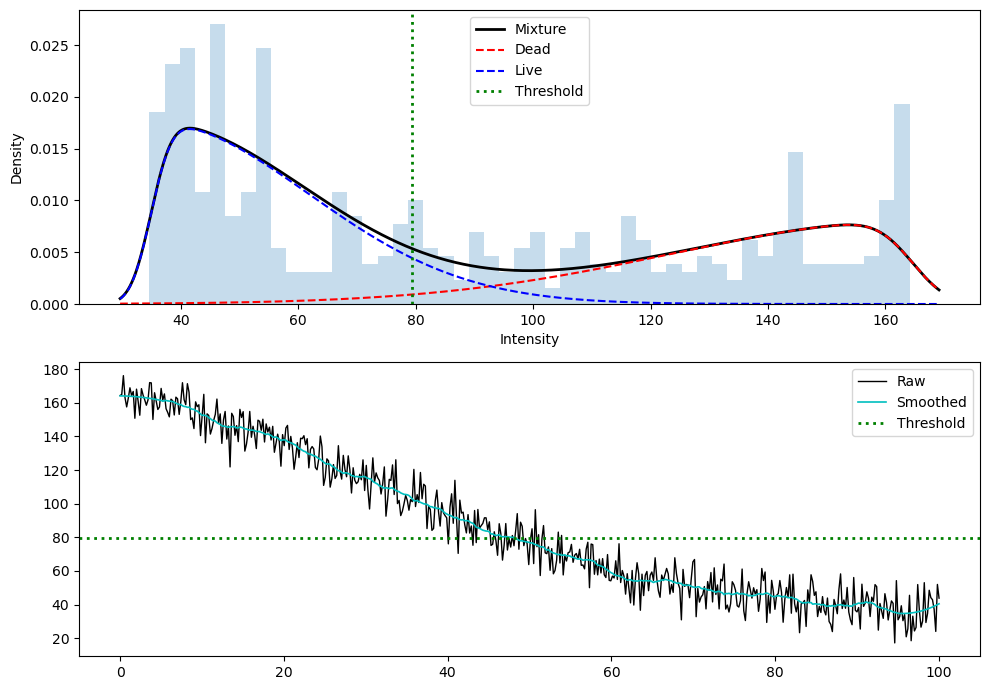

Perzentil-basierte Schwelle: 79.33, Position im Profil: 48.30


In [74]:
#!/usr/bin/env python3
# -*- coding: utf-8 -*-
"""
Bayesian Skew-Normal Mixture mit Perzentil-basierter Dead/Live-Schwelle
(angepasst für nicht-konfokale Propidium-Iodid Mikroskopie)
"""

import numpy as np
from scipy.signal import savgol_filter
from scipy.stats import skewnorm
import jax.numpy as jnp
import jax
import numpyro
import numpyro.distributions as dist
from numpyro.infer import MCMC, NUTS
from jax.scipy.stats import norm
from jax.scipy.special import logsumexp
import matplotlib.pyplot as plt


# ========================
# Hilfsfunktionen
# ========================
def _skewnorm_logpdf(x, loc, scale, alpha):
    z = (x - loc) / scale
    return jnp.log(2.0 / scale) + norm.logpdf(z) + norm.logcdf(alpha * z)


def _skew_mixture_model(X):
    """NumPyro Skew-Normal-Mixture-Modell"""
    # Konvention: w = [dead, live]
    w = numpyro.sample("w", dist.Dirichlet(jnp.array([1.0, 9.0])))

    q10 = jnp.percentile(X, 10.)
    q90 = jnp.percentile(X, 90.)
    sX = jnp.std(X)

    loc_dead = numpyro.sample("loc_dead", dist.Normal(q90, jnp.maximum(5.0, 0.2*sX)))
    loc_live = numpyro.sample("loc_live", dist.Normal(q10, jnp.maximum(5.0, 0.2*sX)))

    scale_dead = numpyro.sample("scale_dead", dist.HalfNormal(jnp.maximum(5.0, 0.3*sX)))
    scale_live = numpyro.sample("scale_live", dist.HalfNormal(jnp.maximum(5.0, 0.3*sX)))

    skew_dead = numpyro.sample("skew_dead", dist.Normal(2.0, 3.0))
    skew_live = numpyro.sample("skew_live", dist.Normal(-2.0, 3.0))

    log_prob_dead = _skewnorm_logpdf(X, loc_dead, scale_dead, skew_dead)
    log_prob_live = _skewnorm_logpdf(X, loc_live, scale_live, skew_live)

    log_probs = jnp.stack([jnp.log(w[0]) + log_prob_dead, jnp.log(w[1]) + log_prob_live], axis=-1)
    log_sum = logsumexp(log_probs, axis=-1)
    numpyro.factor("obs", log_sum.sum())


# ========================
# Hauptfunktion
# ========================
def percentile_threshold(
    intensity_profile,
    x_pos=None,
    dead_percentile=5,
    smooth=True,
    window_length=51,
    polyorder=2,
    num_samples=1200,
    num_warmup=800,
    seed=0,
    plot=False
):
    """
    Schätzt die Schwelle zwischen Live/Dead auf Basis eines radialen Fluoreszenzprofils.
    Bayesian Skew-Normal-Mixture + 5%-Perzentilregel der Dead-Fraktion.

    Parameter
    ---------
    intensity_profile : array
        1D Intensitätsprofil (z.B. radial)
    x_pos : array, optional
        Positionen (gleiche Länge wie profile)
    dead_percentile : float
        Prozent-Anteil der toten Fraktion, die außen ausgeschlossen wird (z.B. 5%)
    smooth : bool
        Ob das Profil mit Savitzky-Golay gefiltert werden soll
    plot : bool
        Optional: Diagramme anzeigen

    Rückgabe
    --------
    threshold_intensity : float
        Intensitätsschwelle
    threshold_position : float
        Position im Profil (falls x_pos gegeben)
    samples : dict
        Posterior-Samples
    """

    # --- Smoothing ---
    X = np.copy(intensity_profile)
    if smooth:
        X = savgol_filter(X, window_length=window_length, polyorder=polyorder)

    # --- Bayesian Fit ---
    kernel = NUTS(_skew_mixture_model)
    mcmc = MCMC(kernel, num_samples=num_samples, num_warmup=num_warmup)
    mcmc.run(jax.random.PRNGKey(seed), X=X)
    samples = mcmc.get_samples()

    xs = np.linspace(np.min(X)-5, np.max(X)+5, 2000)
    thresholds = []

    for i in range(len(samples["loc_dead"])):
        ld = samples["loc_dead"][i]
        sd = samples["scale_dead"][i]
        kd = samples["skew_dead"][i]
        ll = samples["loc_live"][i]
        sl = samples["scale_live"][i]
        kl = samples["skew_live"][i]
        ww = samples["w"][i]

        pdf_d = ww[0] * skewnorm.pdf(xs, a=kd, loc=ld, scale=sd)
        pdf_l = ww[1] * skewnorm.pdf(xs, a=kl, loc=ll, scale=sl)
        post_dead = pdf_d / (pdf_d + pdf_l + 1e-12)

        mass = post_dead / post_dead.sum()
        cumsum = np.cumsum(mass)
        alpha = dead_percentile / 200.0  # z.B. 5% => 0.025
        lower_idx = np.searchsorted(cumsum, alpha)
        upper_idx = np.searchsorted(cumsum, 1-alpha)
        thresholds.append(xs[lower_idx])

    threshold_intensity = np.mean(thresholds)
    threshold_position = None
    if x_pos is not None:
        idx = np.argmin(np.abs(X - threshold_intensity))
        threshold_position = x_pos[idx]


    # --- Plot optional ---
    if plot:
        w_post = np.mean(np.array(samples["w"]), axis=0)
        loc_dead_post = np.mean(np.array(samples["loc_dead"]))
        loc_live_post = np.mean(np.array(samples["loc_live"]))
        scale_dead_post = np.mean(np.array(samples["scale_dead"]))
        scale_live_post = np.mean(np.array(samples["scale_live"]))
        skew_dead_post = np.mean(np.array(samples["skew_dead"]))
        skew_live_post = np.mean(np.array(samples["skew_live"]))

        xs_f = np.linspace(np.min(X)-5, np.max(X)+5, 1000)
        pdf_dead = w_post[0]*skewnorm.pdf(xs_f, a=skew_dead_post, loc=loc_dead_post, scale=scale_dead_post)
        pdf_live = w_post[1]*skewnorm.pdf(xs_f, a=skew_live_post, loc=loc_live_post, scale=scale_live_post)

        plt.figure(figsize=(10,7))
        plt.subplot(2,1,1)
        plt.hist(X, bins=50, density=True, alpha=0.25)
        plt.plot(xs_f, pdf_dead+pdf_live, 'k-', lw=2, label='Mixture')
        plt.plot(xs_f, pdf_dead, 'r--', lw=1.5, label='Dead')
        plt.plot(xs_f, pdf_live, 'b--', lw=1.5, label='Live')
        plt.axvline(threshold_intensity, color='g', linestyle=':', lw=2, label='Threshold')
        plt.legend(); plt.xlabel("Intensity"); plt.ylabel("Density")

        plt.subplot(2,1,2)
        plt.plot(x_pos if x_pos is not None else np.arange(len(X)), intensity_profile, 'k-', lw=1, label="Raw")
        plt.plot(x_pos if x_pos is not None else np.arange(len(X)), X, 'c-', lw=1.2, label="Smoothed")
        plt.axhline(threshold_intensity, color='g', linestyle=':', lw=2, label='Threshold')
        plt.legend(); plt.tight_layout()
        plt.show()

    return threshold_intensity, threshold_position, samples


# ========================
# Test / Beispiel
# ========================
if __name__ == "__main__":
    # Beispiel: simuliertes fallendes Sigmoid
    x_pos = np.linspace(0, 100, 500)

    def sigmoid(x, x0=30, k=-0.05, low=30, high=200):
        return low + (high-low)/(1+np.exp(-k*(x-x0)))

    intensity_profile = sigmoid(x_pos) + np.random.normal(0, 8, size=x_pos.shape)

    threshold, pos, dead_samples = percentile_threshold(
        intensity_profile, x_pos=x_pos, dead_percentile=5, plot=True
    )
    print(f"Perzentil-basierte Schwelle: {threshold:.2f}, Position im Profil: {pos:.2f}")


sample: 100%|██████████| 2000/2000 [00:02<00:00, 718.25it/s, 7 steps of size 3.27e-01. acc. prob=0.72]  


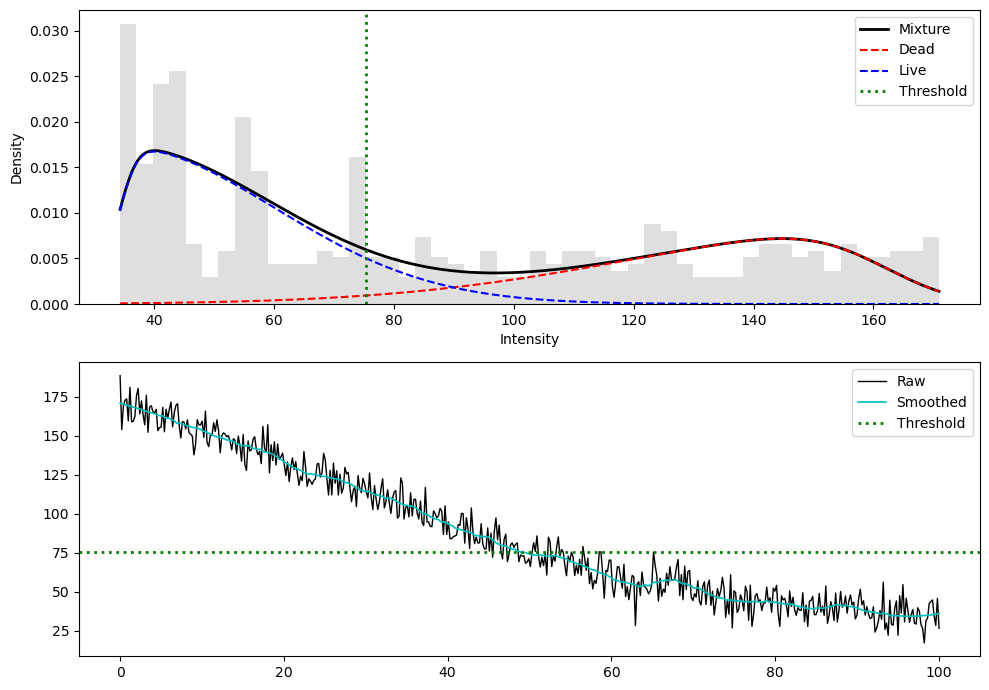

Perzentil-basierte Schwelle: 75.41, Position im Profil: 48.90


In [69]:
#!/usr/bin/env python3
# -*- coding: utf-8 -*-
"""
Bayesian Skew-Normal Mixture mit Perzentil-basierter Dead/Live-Schwelle
(angepasst für nicht-konfokale Propidium-Iodid Mikroskopie)
"""

import numpy as np
from scipy.signal import savgol_filter
from scipy.stats import skewnorm
import jax.numpy as jnp
import jax
import numpyro
import numpyro.distributions as dist
from numpyro.infer import MCMC, NUTS
from jax.scipy.stats import norm
from jax.scipy.special import logsumexp
import matplotlib.pyplot as plt


# ========================
# Hilfsfunktionen
# ========================
def _skewnorm_logpdf(x, loc, scale, alpha):
    z = (x - loc) / scale
    return jnp.log(2.0 / scale) + norm.logpdf(z) + norm.logcdf(alpha * z)


def _skew_mixture_model(X):
    """NumPyro Skew-Normal-Mixture-Modell"""
    # Konvention: w = [dead, live]
    w = numpyro.sample("w", dist.Dirichlet(jnp.array([1.0, 9.0])))

    q10 = jnp.percentile(X, 10.)
    q90 = jnp.percentile(X, 90.)
    sX = jnp.std(X)

    # ---- Konfigurierbare Parameterbereiche ----
    LIVE_RANGE = 0.2  # <- kann angepasst werden (Breite der Priorverteilung um q10)
    DEAD_RANGE = 0.2  # <- kann angepasst werden (Breite der Priorverteilung um q90)
    SCALE_FACTOR = 0.3  # <- relative Breite der Skalen-Prioren

    # ---- Lokationen ----
    loc_dead = numpyro.sample("loc_dead", dist.Normal(q90, jnp.maximum(5.0, DEAD_RANGE * sX)))
    loc_live = numpyro.sample("loc_live", dist.Normal(q10, jnp.maximum(5.0, LIVE_RANGE * sX)))

    # ---- Skalen ----
    scale_dead = numpyro.sample("scale_dead", dist.HalfNormal(jnp.maximum(5.0, SCALE_FACTOR * sX)))
    scale_live = numpyro.sample("scale_live", dist.HalfNormal(jnp.maximum(5.0, SCALE_FACTOR * sX)))

    # ---- Schiefe ----
    skew_dead = numpyro.sample("skew_dead", dist.Normal(2.0, 3.0))
    skew_live = numpyro.sample("skew_live", dist.Normal(-2.0, 3.0))

    log_prob_dead = _skewnorm_logpdf(X, loc_dead, scale_dead, skew_dead)
    log_prob_live = _skewnorm_logpdf(X, loc_live, scale_live, skew_live)

    log_probs = jnp.stack([jnp.log(w[0]) + log_prob_dead, jnp.log(w[1]) + log_prob_live], axis=-1)
    log_sum = logsumexp(log_probs, axis=-1)
    numpyro.factor("obs", log_sum.sum())


# ========================
# Hauptfunktion
# ========================
def percentile_threshold(
    intensity_profile,
    x_pos=None,
    dead_percentile=5,
    smooth=True,
    window_length=51,
    polyorder=2,
    num_samples=1200,
    num_warmup=800,
    seed=0,
    plot=False
):
    """
    Schätzt die Schwelle zwischen Live/Dead auf Basis eines radialen Fluoreszenzprofils.
    Bayesian Skew-Normal-Mixture + 5%-Perzentilregel der Dead-Fraktion.
    """

    # --- Smoothing ---
    X = np.copy(intensity_profile)
    if smooth:
        X = savgol_filter(X, window_length=window_length, polyorder=polyorder)

    # --- Bayesian Fit ---
    kernel = NUTS(_skew_mixture_model)
    mcmc = MCMC(kernel, num_samples=num_samples, num_warmup=num_warmup)
    mcmc.run(jax.random.PRNGKey(seed), X=X)
    samples = mcmc.get_samples()

    # engerer Bereich, um falsche Schwellen zu vermeiden
    xrange = np.max(X) - np.min(X)
    xs = np.linspace(np.min(X) - 0.05 * xrange, np.max(X) + 0.05 * xrange, 2000)

    thresholds = []
    for i in range(len(samples["loc_dead"])):
        ld = samples["loc_dead"][i]
        sd = samples["scale_dead"][i]
        kd = samples["skew_dead"][i]
        ll = samples["loc_live"][i]
        sl = samples["scale_live"][i]
        kl = samples["skew_live"][i]
        ww = samples["w"][i]

        pdf_d = ww[0] * skewnorm.pdf(xs, a=kd, loc=ld, scale=sd)
        pdf_l = ww[1] * skewnorm.pdf(xs, a=kl, loc=ll, scale=sl)
        post_dead = pdf_d / (pdf_d + pdf_l + 1e-12)

        mass = post_dead / post_dead.sum()
        cumsum = np.cumsum(mass)
        alpha = dead_percentile / 200.0  # z.B. 5% => 0.025
        lower_idx = np.searchsorted(cumsum, alpha)
        thresholds.append(xs[lower_idx])

    threshold_intensity = np.mean(thresholds)
    # 🚫 Verhindere, dass Schwelle außerhalb realer Intensitäten liegt:
    threshold_intensity = np.clip(threshold_intensity, np.min(X), np.max(X))

    threshold_position = None
    if x_pos is not None:
        idx = np.argmin(np.abs(X - threshold_intensity))
        threshold_position = x_pos[idx]

    # --- Plot optional ---
    if plot:
        w_post = np.mean(np.array(samples["w"]), axis=0)
        loc_dead_post = np.mean(np.array(samples["loc_dead"]))
        loc_live_post = np.mean(np.array(samples["loc_live"]))
        scale_dead_post = np.mean(np.array(samples["scale_dead"]))
        scale_live_post = np.mean(np.array(samples["scale_live"]))
        skew_dead_post = np.mean(np.array(samples["skew_dead"]))
        skew_live_post = np.mean(np.array(samples["skew_live"]))

        xs_f = np.linspace(np.min(X), np.max(X), 1000)
        pdf_dead = w_post[0]*skewnorm.pdf(xs_f, a=skew_dead_post, loc=loc_dead_post, scale=scale_dead_post)
        pdf_live = w_post[1]*skewnorm.pdf(xs_f, a=skew_live_post, loc=loc_live_post, scale=scale_live_post)

        plt.figure(figsize=(10,7))
        plt.subplot(2,1,1)
        plt.hist(X, bins=50, density=True, alpha=0.25, color='gray')
        plt.plot(xs_f, pdf_dead+pdf_live, 'k-', lw=2, label='Mixture')
        plt.plot(xs_f, pdf_dead, 'r--', lw=1.5, label='Dead')
        plt.plot(xs_f, pdf_live, 'b--', lw=1.5, label='Live')
        plt.axvline(threshold_intensity, color='g', linestyle=':', lw=2, label='Threshold')
        plt.legend(); plt.xlabel("Intensity"); plt.ylabel("Density")

        plt.subplot(2,1,2)
        plt.plot(x_pos if x_pos is not None else np.arange(len(X)), intensity_profile, 'k-', lw=1, label="Raw")
        plt.plot(x_pos if x_pos is not None else np.arange(len(X)), X, 'c-', lw=1.2, label="Smoothed")
        plt.axhline(threshold_intensity, color='g', linestyle=':', lw=2, label='Threshold')
        plt.legend(); plt.tight_layout()
        plt.show()

    return threshold_intensity, threshold_position, samples


# ========================
# Test / Beispiel
# ========================
if __name__ == "__main__":
    # Beispiel: simuliertes fallendes Sigmoid
    x_pos = np.linspace(0, 100, 500)

    def sigmoid(x, x0=30, k=-0.05, low=30, high=200):
        return low + (high-low)/(1+np.exp(-k*(x-x0)))

    intensity_profile = sigmoid(x_pos) + np.random.normal(0, 8, size=x_pos.shape)

    threshold, pos, dead_samples = percentile_threshold(
        intensity_profile, x_pos=x_pos, dead_percentile=5, plot=True
    )
    print(f"Perzentil-basierte Schwelle: {threshold:.2f}, Position im Profil: {pos:.2f}")


In [ ]:
if __name__ == "__main__":
    
    for x0 in [20,50,80]:
        # Beispiel: simuliertes fallendes Sigmoid
        x_pos = np.linspace(0, 100, 500)

        def sigmoid(x, x0=x0, k=-0.05, low=8, high=20):
            return low + (high-low)/(1+np.exp(-k*(x-x0)))

        intensity_profile = sigmoid(x_pos) + np.random.normal(0, .5, size=x_pos.shape)

        threshold, pos, dead_samples = percentile_threshold(
            intensity_profile, x_pos=x_pos, dead_percentile=25, plot=True
        )
        print(f"Perzentil-basierte Schwelle: {threshold:.2f}, Position im Profil: {pos:.2f}")
